# EP3 — Machine Learning Supervisado: Clasificacion y Regresion

**Asignatura:** TLY1101 — Machine Learning | **Seccion:** 002D

**Integrantes del equipo:**
- Martin Higuera
- Gabriel Duran

---

## Declaracion de uso de Inteligencia Artificial

Se utilizaron herramientas de Inteligencia Artificial como apoyo para la redaccion, organizacion y revision del contenido de este notebook. Todo el codigo, los analisis y las justificaciones tecnicas fueron revisados y validados por el equipo. El uso de IA se declara conforme a la politica institucional: https://bibliotecas.duoc.cl/ia

## Fuentes

- https://medium.com/@azizozmen/understanding-multicollinearity-its-impact-on-data-analysis-and-machine-learning-94da6620569e
- https://medium.com/@hhuseyincosgun/which-data-scaling-technique-should-i-use-a1615292061e

### Imports

In [142]:
# Librerias para manipular datasets
import os
import shutil
import math
import warnings

import numpy as np
import pandas as pd

# Visualizacion
import matplotlib.pyplot as plt
import seaborn as sns

# scikit-learn: utilidades generales
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Modelos de regresion (Caso 1)
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

# Metricas de regresion (Caso 1)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Modelos de clasificacion (Caso 2)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Metricas de clasificacion (Caso 2)
from sklearn.metrics import (classification_report, confusion_matrix, roc_curve,
                             roc_auc_score, accuracy_score, precision_score,
                             recall_score, f1_score)

# Configuracion general
sns.set_theme(style="whitegrid")
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)
warnings.filterwarnings("ignore")

print("Librerias importadas correctamente.")

Librerias importadas correctamente.


# Caso 1: Modelamiento de Regresion — Prediccion del Precio de Venta de Autos Usados

## Contexto y objetivo

El objetivo de este caso es predecir el **precio de venta de un auto usado** (variable target `precio_venta_actual`, tal como la define el encargo) a partir de sus caracteristicas: anno del vehiculo, kilometraje, tipo de combustible, tipo de vendedor, transmision, cantidad de propietarios y precio actual del vehiculo nuevo.

Se implementan **dos algoritmos de regresion distintos** — SVR (Support Vector Regressor) y K-Nearest Neighbors Regressor (KNN) — y se comparan sus metricas de desempeno (MSE, RMSE y R2) para seleccionar el mejor modelo.

## 1. Importar librerias

Las librerias especificas del Caso 1 (modelos de regresion y metricas) se importan a continuacion. Las librerias generales de manipulacion de datos, visualizacion y clasificacion ya fueron importadas al inicio del notebook.

In [143]:
# Modelos de regresion
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

# Metricas de regresion
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("Librerias del Caso 1 importadas correctamente.")

Librerias del Caso 1 importadas correctamente.


## 2. Cargar el dataset

El archivo `car_data.csv` viene separado por coma, pero su encabezado tiene un problema: **contiene solo 8 nombres de columnas mientras cada fila tiene 9 valores** (falta el nombre de la cuarta columna, que corresponde al precio actual del vehiculo nuevo). Si se lee con `pd.read_csv` de forma naive, pandas toma la primera columna como indice y **desplaza todas las etiquetas una posicion** (la columna `kilometraje` quedaria con el valor del precio actual, etc.).

Para corregirlo, se lee el archivo indicando explicitamente los **9 nombres correctos** de columna. La variable target es `precio_venta_actual` (el precio en que el vehiculo esta siendo vendido), tal como la define el encargo.

In [144]:
# Copia de seguridad: no alteramos el archivo original
os.makedirs("copy", exist_ok=True)
shutil.copy("data_sets/car_data.csv", "copy/car_data_copy.csv")

# Nombres correctos de las 9 columnas (el encabezado del CSV solo tiene 8)
columnas_auto = ["nom_auto", "anno", "precio_venta_actual", "precio_actual",
                 "kilometraje", "tipo_combustible", "tipo_vendedor", "transmision", "propietario"]

df_auto = pd.read_csv("copy/car_data_copy.csv", names=columnas_auto, header=0)

print(f"Registros: {df_auto.shape[0]} | Columnas: {df_auto.shape[1]}")
df_auto.head(10)

Registros: 301 | Columnas: 9


,nom_auto,anno,precio_venta_actual,precio_actual,kilometraje,tipo_combustible,tipo_vendedor,transmision,propietario
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
5,vitara brezza,2018,9.25,9.83,2071,Diesel,Dealer,Manual,0
6,ciaz,2015,6.75,8.12,18796,Petrol,Dealer,Manual,0
7,s cross,2015,6.50,8.61,33429,Diesel,Dealer,Manual,0
8,ciaz,2016,8.75,8.89,20273,Diesel,Dealer,Manual,0
9,ciaz,2015,7.45,8.92,42367,Diesel,Dealer,Manual,0


## 3. Analisis exploratorio del dataset

In [145]:
print("Tipos de datos:")
print(df_auto.dtypes)

print("\nValores nulos por columna:")
print(df_auto.isnull().sum())

print(f"\nRegistros duplicados: {df_auto.duplicated().sum()}")

df_auto.describe().T

Tipos de datos:
nom_auto                   str
anno                     int64
precio_venta_actual    float64
precio_actual          float64
kilometraje              int64
tipo_combustible           str
tipo_vendedor              str
transmision                str
propietario              int64
dtype: object

Valores nulos por columna:
nom_auto               0
anno                   0
precio_venta_actual    0
precio_actual          0
kilometraje            0
tipo_combustible       0
tipo_vendedor          0
transmision            0
propietario            0
dtype: int64

Registros duplicados: 2


,count,mean,std,min,25%,50%,75%,max
anno,301.0,2013.627907,2.891554,2003.00,2012.0,2014.0,2016.0,2018.0
precio_venta_actual,301.0,4.661296,5.082812,0.10,0.9,3.6,6.0,35.0
precio_actual,301.0,7.628472,8.644115,0.32,1.2,6.4,9.9,92.6
kilometraje,301.0,36947.205980,38886.883882,500.00,15000.0,32000.0,48767.0,500000.0
propietario,301.0,0.043189,0.247915,0.00,0.0,0.0,0.0,3.0


## 4. Preprocesamiento de variables categoricas (One-Hot Encoding)

La variable `nom_auto` (modelo del automovil) tiene **98 categorías distintas** en solo 301 registros: cada modelo aparece 1 o 2 veces, por lo que no aporta informacion generalizable y se elimina del modelado.

Las variables categoricas `tipo_combustible`, `tipo_vendedor` y `transmision` se convierten a variables numericas mediante **One-Hot Encoding** con `drop_first=True` para evitar la trampa de las variables dummy (multicolinealidad perfecta entre las columnas generadas).

In [146]:
# Distribucion de las variables categoricas
for columna in ["tipo_combustible", "tipo_vendedor", "transmision", "propietario"]:
    print(f"--- {columna} ---")
    print(df_auto[columna].value_counts().to_string(), "\n")

print(f"Modelos de auto distintos en nom_auto: {df_auto['nom_auto'].nunique()}")

--- tipo_combustible ---
tipo_combustible
Petrol    239
Diesel     60
CNG         2 

--- tipo_vendedor ---
tipo_vendedor
Dealer        195
Individual    106 

--- transmision ---
transmision
Manual       261
Automatic     40 

--- propietario ---
propietario
0    290
1     10
3      1 

Modelos de auto distintos en nom_auto: 98


In [147]:
# One-Hot Encoding (drop_first=True evita multicolinealidad perfecta)
df_reg = pd.get_dummies(
    df_auto.drop(columns=["nom_auto"]),
    columns=["tipo_combustible", "tipo_vendedor", "transmision"],
    drop_first=True,
    dtype=int
)

print("Columnas despues del One-Hot Encoding:")
print(list(df_reg.columns))
df_reg.head()

Columnas despues del One-Hot Encoding:
['anno', 'precio_venta_actual', 'precio_actual', 'kilometraje', 'propietario', 'tipo_combustible_Diesel', 'tipo_combustible_Petrol', 'tipo_vendedor_Individual', 'transmision_Manual']


,anno,precio_venta_actual,precio_actual,kilometraje,propietario,tipo_combustible_Diesel,tipo_combustible_Petrol,tipo_vendedor_Individual,transmision_Manual
0,2014,3.35,5.59,27000,0,0,1,0,1
1,2013,4.75,9.54,43000,0,1,0,0,1
2,2017,7.25,9.85,6900,0,0,1,0,1
3,2011,2.85,4.15,5200,0,0,1,0,1
4,2014,4.60,6.87,42450,0,1,0,0,1


## 5. Analisis de correlación

Se expone el nivel de correlación entre la variable a predecir (`precio_venta_actual`) y las variables predictoras, la matriz de correlación entre las predictoras y su mapa de calor.

Correlacion de cada predictora con precio_venta_actual:

precio_actual               0.879
tipo_combustible_Diesel     0.552
anno                        0.236
kilometraje                 0.029
propietario                -0.088
transmision_Manual         -0.367
tipo_combustible_Petrol    -0.541
tipo_vendedor_Individual   -0.551


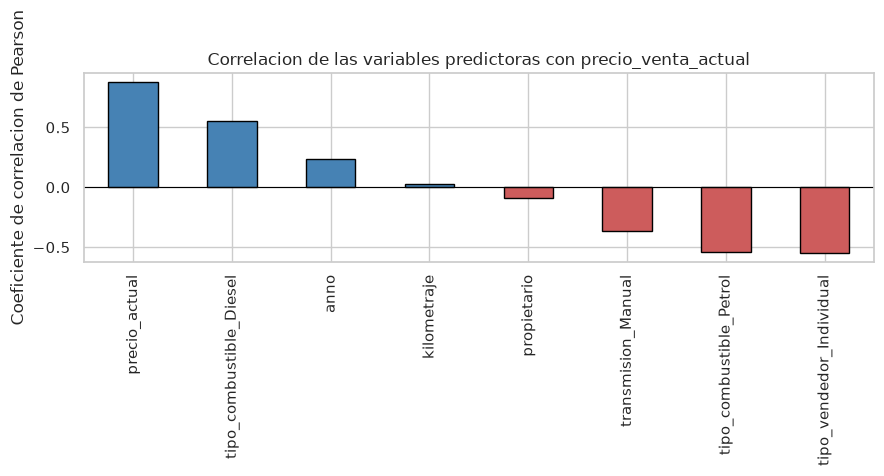

In [148]:
correlacion_precio = df_reg.corr()["precio_venta_actual"].drop("precio_venta_actual").sort_values(ascending=False)
print("Correlacion de cada predictora con precio_venta_actual:\n")
print(correlacion_precio.round(3).to_string())

plt.figure(figsize=(9, 4.5))
colores = ["steelblue" if v >= 0 else "indianred" for v in correlacion_precio.values]
correlacion_precio.plot(kind="bar", color=colores, edgecolor="black")
plt.axhline(0, color="black", lw=0.8)
plt.title("Correlacion de las variables predictoras con precio_venta_actual")
plt.ylabel("Coeficiente de correlacion de Pearson")
plt.tight_layout()
plt.show()

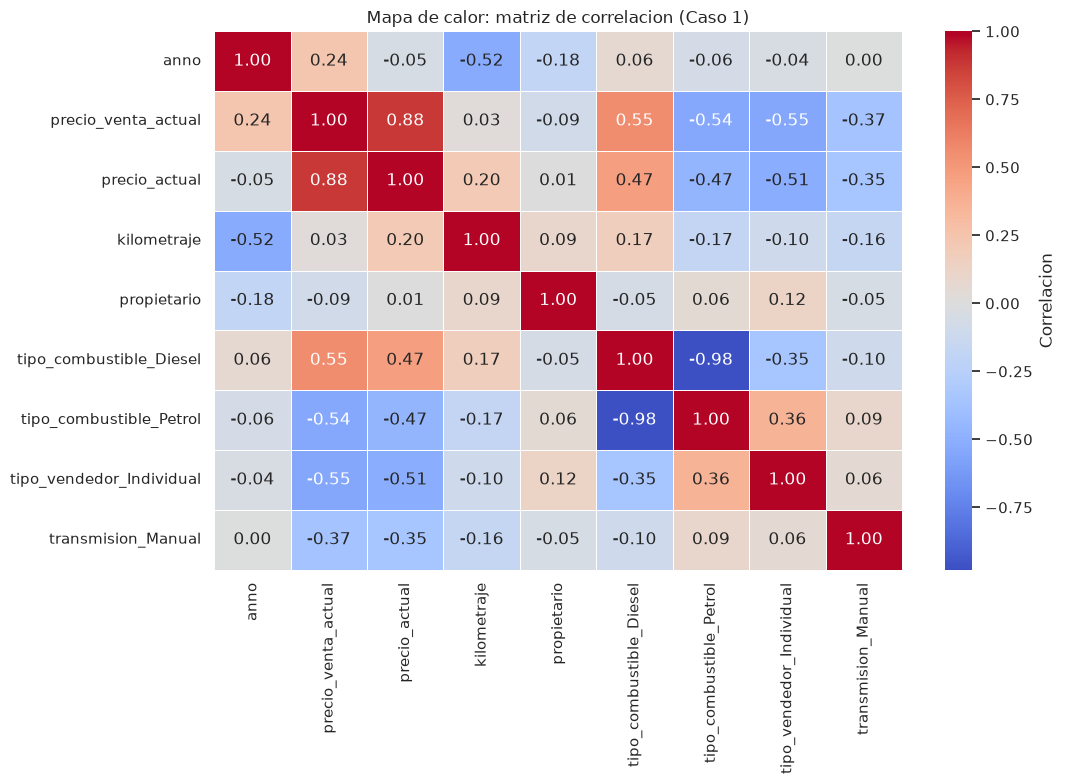

In [149]:
plt.figure(figsize=(11, 8))
sns.heatmap(df_reg.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0,
            linewidths=0.5, cbar_kws={"label": "Correlacion"})
plt.title("Mapa de calor: matriz de correlacion (Caso 1)")
plt.tight_layout()
plt.show()

**Interpretacion:** la variable mas correlaciónada con el precio de venta es `precio_actual` (precio del vehiculo nuevo), seguida de `anno`: los autos mas nuevos y los modelos mas caros de nuevos se venden mas caros de usados. El `kilometraje` se correlacióna de forma negativa: a mayor recorrido, menor precio de venta. Las variables categoricas codificadas aportan informacion menor pero complementaria.

## 6. Separar caracteristicas (X) y variable objetivo (y)

Se utiliza el sufijo `_reg` en los nombres de las variables para no chocar con las del Caso 2.

In [150]:
X_reg = df_reg.drop(columns=["precio_venta_actual"])
y_reg = df_reg["precio_venta_actual"]

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

print(f"Entrenamiento: {X_train_r.shape[0]} registros | Prueba: {X_test_r.shape[0]} registros")
print(f"Predictoras utilizadas ({X_reg.shape[1]}): {list(X_reg.columns)}")

Entrenamiento: 240 registros | Prueba: 61 registros
Predictoras utilizadas (8): ['anno', 'precio_actual', 'kilometraje', 'propietario', 'tipo_combustible_Diesel', 'tipo_combustible_Petrol', 'tipo_vendedor_Individual', 'transmision_Manual']


## 7. Escalamiento de caracteristicas (StandardScaler)

SVR y KNN trabajan con **distancias**, por lo que son sensibles a las magnitudes de las variables (p. ej. `kilometraje` supera los 200.000 km mientras `propietario` toma valores entre 0 y 3). Se aplica `StandardScaler` ajustando (`fit`) **solo con el conjunto de entrenamiento** y transformando ambos conjuntos, para evitar fuga de datos.

In [151]:
escalador_reg = StandardScaler()
X_train_r_sc = escalador_reg.fit_transform(X_train_r)   # fit solo con entrenamiento
X_test_r_sc = escalador_reg.transform(X_test_r)          # solo transform en prueba

pd.DataFrame(X_train_r_sc, columns=X_reg.columns).head(10).round(3)

,anno,precio_actual,kilometraje,propietario,tipo_combustible_Diesel,tipo_combustible_Petrol,tipo_vendedor_Individual,transmision_Manual
0,-1.970,-0.754,-0.276,3.528,-0.480,0.493,1.338,0.378
1,1.156,-0.731,-0.814,-0.186,-0.480,0.493,1.338,0.378
2,-1.970,-0.749,0.299,-0.186,-0.480,0.493,1.338,0.378
3,0.462,-0.079,-0.036,-0.186,-0.480,0.493,-0.747,0.378
4,0.809,-0.670,-0.690,-0.186,-0.480,0.493,1.338,0.378
5,0.114,3.170,0.084,-0.186,2.082,-2.026,-0.747,-2.646
6,0.462,2.574,0.060,-0.186,2.082,-2.026,-0.747,-2.646
7,0.462,0.068,-0.448,-0.186,-0.480,0.493,-0.747,0.378
8,-0.928,-0.749,0.898,-0.186,-0.480,0.493,1.338,0.378
9,-0.580,-0.171,0.334,-0.186,2.082,-2.026,-0.747,0.378


## 8. Modelo SVR (Support Vector Regressor)

Se crea y entrena el modelo SVR con los parametros indicados en el encargo: `kernel='rbf'`, `C=1.0` y `epsilon=0.1`.

In [152]:
svr = SVR(kernel="rbf", C=1.0, epsilon=0.1)
svr.fit(X_train_r_sc, y_train_r)

pred_svr_test = svr.predict(X_test_r_sc)
pred_svr_train = svr.predict(X_train_r_sc)

mse_svr = mean_squared_error(y_test_r, pred_svr_test)
rmse_svr = np.sqrt(mse_svr)
mae_svr = mean_absolute_error(y_test_r, pred_svr_test)
r2_svr_test = r2_score(y_test_r, pred_svr_test)
r2_svr_train = r2_score(y_train_r, pred_svr_train)

print("=== SVR (kernel='rbf', C=1.0, epsilon=0.1) ===")
print(f"MSE : {mse_svr:.4f}")
print(f"RMSE: {rmse_svr:.4f}")
print(f"MAE : {mae_svr:.4f}")
print(f"R2 prueba:        {r2_svr_test:.4f}")
print(f"R2 entrenamiento: {r2_svr_train:.4f}")

=== SVR (kernel='rbf', C=1.0, epsilon=0.1) ===
MSE : 5.1198
RMSE: 2.2627
MAE : 1.0108
R2 prueba:        0.7777
R2 entrenamiento: 0.6565


**Interpretacion:** el SVR alcanza un R2 de 0,7777 en prueba, es decir, explica aproximadamente el 78% de la variabilidad del precio de venta. Su RMSE de 2,2627 (en lakhs, la unidad del dataset) indica que el error tipico de prediccion es de unos 2,26 lakhs (~2,26 millones de pesos). El R2 en entrenamiento (0,6565) es incluso menor que en prueba, por lo que no hay sobreajuste: el modelo se queda corto (subajuste) y no logra captar toda la complejidad del problema con esta configuracion.

## 9. Modelo K-Nearest Neighbors Regressor (KNN)

Se crea y entrena el modelo KNN con `n_neighbors=7`, como indica el encargo.

In [153]:
knn = KNeighborsRegressor(n_neighbors=7)
knn.fit(X_train_r_sc, y_train_r)

pred_knn_test = knn.predict(X_test_r_sc)
pred_knn_train = knn.predict(X_train_r_sc)

mse_knn = mean_squared_error(y_test_r, pred_knn_test)
rmse_knn = np.sqrt(mse_knn)
mae_knn = mean_absolute_error(y_test_r, pred_knn_test)
r2_knn_test = r2_score(y_test_r, pred_knn_test)
r2_knn_train = r2_score(y_train_r, pred_knn_train)

print("=== KNN (n_neighbors=7) ===")
print(f"MSE : {mse_knn:.4f}")
print(f"RMSE: {rmse_knn:.4f}")
print(f"MAE : {mae_knn:.4f}")
print(f"R2 prueba:        {r2_knn_test:.4f}")
print(f"R2 entrenamiento: {r2_knn_train:.4f}")

=== KNN (n_neighbors=7) ===
MSE : 1.6512
RMSE: 1.2850
MAE : 0.7790
R2 prueba:        0.9283
R2 entrenamiento: 0.8906


**Interpretacion:** el KNN alcanza un R2 de 0,9283 en prueba: explica cerca del 93% de la variabilidad del precio. Su RMSE de 1,2850 reduce a menos de la mitad el error tipico del SVR. La pequena diferencia entre el R2 de entrenamiento (0,8906) y el de prueba (0,9283) indica que el modelo generaliza bien, sin sobreajuste.

## 10. Comparacion gráfica: valores reales vs. predichos

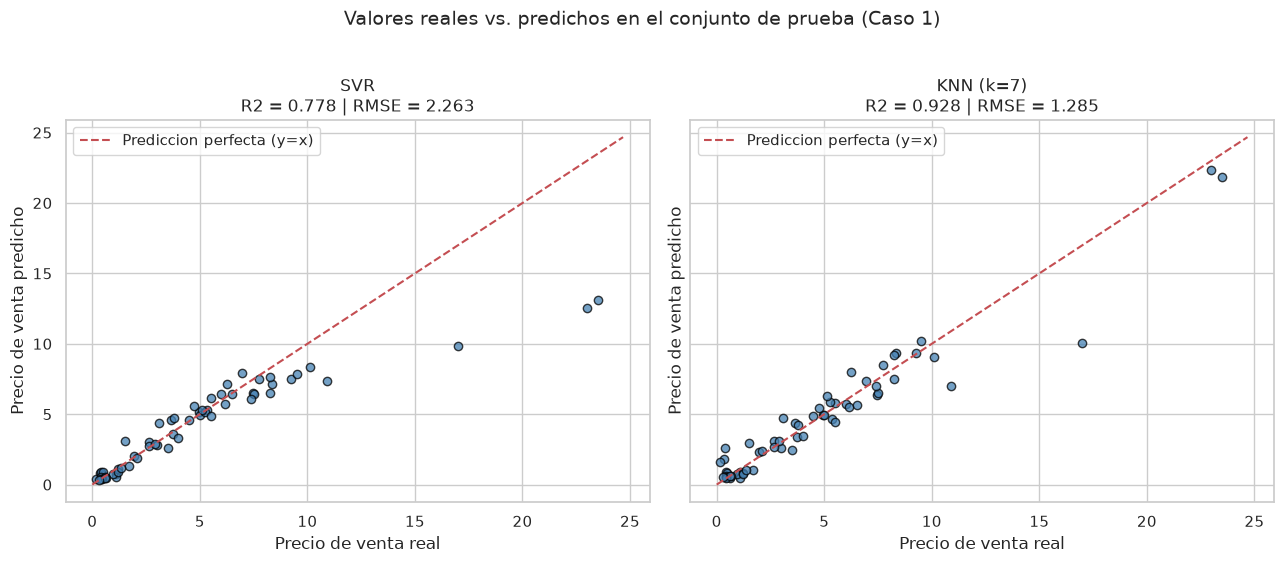

In [154]:
fig, ejes = plt.subplots(1, 2, figsize=(13, 5.5), sharex=True, sharey=True)

for eje, (nombre, pred) in zip(ejes, [("SVR", pred_svr_test), ("KNN (k=7)", pred_knn_test)]):
    eje.scatter(y_test_r, pred, alpha=0.75, edgecolor="black", color="steelblue")
    limite = max(y_test_r.max(), pred.max()) * 1.05
    eje.plot([0, limite], [0, limite], "r--", label="Prediccion perfecta (y=x)")
    eje.set_title(f"{nombre}\nR2 = {r2_score(y_test_r, pred):.3f} | RMSE = {np.sqrt(mean_squared_error(y_test_r, pred)):.3f}")
    eje.set_xlabel("Precio de venta real")
    eje.set_ylabel("Precio de venta predicho")
    eje.legend()

plt.suptitle("Valores reales vs. predichos en el conjunto de prueba (Caso 1)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 11. Tabla resumen de modelos de regresion

In [155]:
tabla_regresion = pd.DataFrame({
    "Modelo": ["SVR (rbf, C=1.0, epsilon=0.1)", "KNN (n_neighbors=7)"],
    "MSE": [mse_svr, mse_knn],
    "RMSE": [rmse_svr, rmse_knn],
    "MAE": [mae_svr, mae_knn],
    "R2 prueba": [r2_svr_test, r2_knn_test],
    "R2 entrenamiento": [r2_svr_train, r2_knn_train],
}).set_index("Modelo")

tabla_regresion.round(4)

,MSE,RMSE,MAE,R2 prueba,R2 entrenamiento
Modelo,,,,,
"SVR (rbf, C=1.0, epsilon=0.1)",5.1198,2.2627,1.0108,0.7777,0.6565
KNN (n_neighbors=7),1.6512,1.2850,0.7790,0.9283,0.8906


## 12. ¿Cual modelo entrega una mejor prediccion? ¿Por que?

El **KNN predice mejor** que el SVR en todas las metricas: reduce el MSE en un 68% (de 5,1198 a 1,6512), el RMSE de 2,2627 a 1,2850 y eleva el R2 de prueba de 0,7777 a 0,9283 (15 puntos porcentuales).

Esto se debe a que el precio de venta de un auto usado depende fuertemente de su precio actual y de su anno, variables con las que los vecinos mas cercanos en el espacio escalado coinciden de forma natural. El SVR con kernel rbf y epsilon=0,1, en cambio, se queda corto (subajuste) para este volumen de datos.

**Conclusion del Caso 1:** el mejor modelo de regresion es **KNeighborsRegressor con n_neighbors=7**, con RMSE de 1,2850 y R2 de 0,9283 en prueba, sin evidencia de sobreajuste.

---

# Caso 2: Modelamiento de Clasificacion — Prediccion de Cancer de Mama

# Contexto 

El cáncer de mama es un tipo de cáncer que se forma en las células de las mamas.
Después del cáncer de piel, el cáncer de mama es el tipo más común diagnosticado en mujeres en todo el
mundo.
El cáncer de mama se puede presentar tanto en hombres como en mujeres; sin embargo, es mucho más
común en las mujeres.
El considerable apoyo para la concientización y la financiación de investigaciones sobre el cáncer de mama
ha ayudado a crear avances en el diagnóstico y tratamiento de esta enfermedad.
Las tasas de supervivencia al cáncer de mama han aumentado y el número de muertes asociadas con esta enfermedad está disminuyendo constantemente, en
gran medida debido a factores como la detección temprana, un nuevo enfoque de tratamiento personalizado y una mejor comprensión de la enfermedad.


Este DataSet contiene las mediciones celulares a partir de imagenes digitalziadas de la masa de la mama

# Analisis del breast_cancer.csv

In [156]:
df_breast = pd.read_csv("data_sets/breast_cancer.csv")

#vista rapido de datos
df_breast.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


Generamos una copia para no alterar el contenido original

In [157]:
import shutil 

#Hacemos una copia de los datos
shutil.copy("data_sets/breast_cancer.csv", "copy/breast_can_copy.csv")

'copy/breast_can_copy.csv'

In [158]:
#Guardamos la copia en una variable
df_breast_copia = pd.read_csv("copy/breast_can_copy.csv")

df_breast_copia.tail()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
564,926424,1,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,1.1760,1.256,7.673,158.70,0.010300,0.02891,0.05198,0.02454,0.01114,0.004239,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,1,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,0.7655,2.463,5.203,99.04,0.005769,0.02423,0.03950,0.01678,0.01898,0.002498,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,1,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,0.4564,1.075,3.425,48.55,0.005903,0.03731,0.04730,0.01557,0.01318,0.003892,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,1,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,0.7260,1.595,5.772,86.22,0.006522,0.06158,0.07117,0.01664,0.02324,0.006185,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400
568,92751,0,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,0.1587,0.05884,0.3857,1.428,2.548,19.15,0.007189,0.00466,0.00000,0.00000,0.02676,0.002783,9.456,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039


## Analisis exploratorio de los datos

Revisamos la cantidad la cantidad de filas y columnas

In [159]:
print(f"Cantidad de columnas {df_breast_copia.shape[1]}")
print(f"Cantidad de registros {df_breast_copia.shape[0]}")

Cantidad de columnas 32
Cantidad de registros 569


Revisamos los tipos de datos que contiene

In [160]:

df_breast_copia.dtypes

id                           int64
diagnosis                    int64
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst           float64
compactness_worst          float64
concavity_worst     

In [161]:
print(f"Cantidad de floats {sum(df_breast_copia.dtypes == float)}")
print(f"Cantidad de Integers {sum(df_breast_copia.dtypes == int )}")
print(f"Cantidad de variables que no sean las dos anteriores: \n { sum(tipo != int and tipo != float and tipo != 'int64' and tipo != 'float64' for tipo in df_breast_copia.dtypes) }")

Cantidad de floats 30
Cantidad de Integers 2
Cantidad de variables que no sean las dos anteriores: 
 0


## Revision de nulos

In [162]:

conteo_nulos_por_columna = df_breast_copia.isnull().sum()
print("Valores nulos por columna:")
print(conteo_nulos_por_columna)

Valores nulos por columna:
id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64


In [163]:

nulos_total = df_breast_copia.isnull().sum().sum()
print("Valores nulos por columna:")
print(nulos_total)

Valores nulos por columna:
0


Este DataSet no requiere tratamiento de nulos al no tener nulos

## Seleccion de datos

En esta seccion eliminaremos los datos los cuales no sean relevantes **Para saber si una paciente podria padecer de cancer** , Para ello se tomara en cuenta que una persona puede padecer de cancer de mama debido a lo siguiente :

- Un bulto o engrosamiento en la mama que se siente diferente del tejido que la rodea.
-  Cambio de tamaño, forma o aspecto de una mama.
-  Cambios en la piel que se encuentra sobre la mama, como formación de hoyuelos.
- La inversión reciente del pezón
- Descamación, desprendimiento de la piel, formación de costras y pelado del área pigmentada de la piel que rodea el pezón (areola) o la piel de
la mama
- Enrojecimiento o pequeños orificios en la piel que se encuentra sobre tu mama, como la piel de una naranja.

## Variable target : diagnosis

Con esta variable como target podremos predecir el diagnostico de una persona, como primer paso eliminaremos la columna que a primera vista no aporta , el cual es el numero de identificacion del registro

In [164]:
#df_breast_copia["id"]
df_breast_copia = df_breast_copia.drop(columns=["id"])

df_breast_copia.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


Id ha sido eliminado exitosamente. En este dataset no existe la columna **'Unnamed: 32'** (solo tiene 32 columnas: id, diagnosis y las 30 mediciones), por lo que la verificación automática confirma que no hay nada que eliminar y **df_limpio queda con 31 columnas** (diagnosis + 30 features).

In [165]:
if 'Unnamed: 32' in df_breast_copia.columns:
    df_breast_copia = df_breast_copia.drop(columns=['Unnamed: 32'])

if "Unnamed: 32" in df_breast_copia.index : 
    print("Aun esta la columna")
else : 
    print("Columna exitoasmente eliminada")


df_limpio = df_breast_copia

df_limpio.head()

Columna exitoasmente eliminada


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


# Analisis de la variable target y su correlación con las variables con las predictoras

Se procede a analizar la correlación entre las variables para decidir cuales son relevantes , con el fin de evitar problemas en el entrenamiento

### Analisis de distribucion de los valores en la columna diagnosis

Distribución porcentual de la variable 'diagnosis':
 - Benigno (0): 62.74%
 - Maligno (1): 37.26%


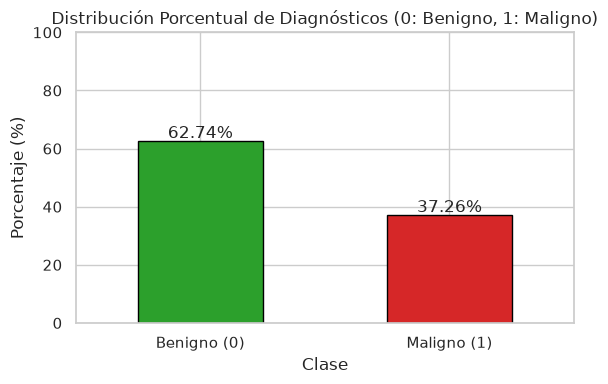

In [166]:
#Distribucion en procentaje
distribucion_porcentual = df_breast_copia['diagnosis'].value_counts(normalize=True) * 100

print("Distribución porcentual de la variable 'diagnosis':")
for clase, porcentaje in distribucion_porcentual.items():
    nombre_clase = "Maligno (1)" if clase == 1 else "Benigno (0)"
    print(f" - {nombre_clase}: {porcentaje:.2f}%")

# Grafico
plt.figure(figsize=(6, 4))
ax = distribucion_porcentual.plot(kind='bar', color=['#2ca02c', '#d62728'], edgecolor='black')
plt.title('Distribución Porcentual de Diagnósticos (0: Benigno, 1: Maligno)')
plt.xlabel('Clase')
plt.ylabel('Porcentaje (%)')
plt.xticks(ticks=[0, 1], labels=['Benigno (0)', 'Maligno (1)'], rotation=0)

# Anotación numérica sobre cada barra
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}%", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.ylim(0, 100)
plt.tight_layout()
plt.show()

Podemos ver como en los registros , mas de la mitad presentan ser 0 , osea benignos. Esto puede decirnos que el dataset tiene una carga hacia casos de diagnosis negativa (osea tumores no malignos)

### Examen de la variable a predecir (diagnosis)

El encargo pide examinar la variable a predecir y, de ser necesario, aplicar una transformacion a las etiquetas. A continuacion se verifica su contenido:

In [167]:
print("Valores unicos de 'diagnosis':", df_limpio['diagnosis'].unique())
print("Tipo de dato de 'diagnosis':", df_limpio['diagnosis'].dtype)

Valores unicos de 'diagnosis': [1 0]
Tipo de dato de 'diagnosis': int64


**No se aplica transformacion a las etiquetas:** la variable `diagnosis` ya contiene valores numericos 0 (Benigno) y 1 (Maligno) de tipo entero, que es exactamente el formato que esperan los algoritmos de clasificacion de scikit-learn. Codificarla nuevamente (por ejemplo con LabelEncoder) seria redundante y representarla en one-hot no tiene sentido para una variable target binaria. Por lo tanto, se trabaja directamente con la codificacion 0/1 existente.

### Analisis de los tipos de datos en el data y correlación con la variable target

Se logra ver que todas son de tipo numerico 

In [168]:
# Exponemos el nivel de correlación entre la columna a predecir ('diagnosis') y las predictoras
# Calculamos la correlación y la ordenamos de mayor a menor
correlacion_diagnosis = df_breast_copia.corr()['diagnosis'].sort_values(ascending=False)
#Se reguardan las columnas en correlacion_diagnosis para luego analizarlas


print("Correlación de las variables predictoras con 'diagnosis':\n")
print(correlacion_diagnosis)

Correlación de las variables predictoras con 'diagnosis':

diagnosis                  1.000000
concave points_worst       0.793566
perimeter_worst            0.782914
concave points_mean        0.776614
radius_worst               0.776454
perimeter_mean             0.742636
area_worst                 0.733825
radius_mean                0.730029
area_mean                  0.708984
concavity_mean             0.696360
concavity_worst            0.659610
compactness_mean           0.596534
compactness_worst          0.590998
radius_se                  0.567134
perimeter_se               0.556141
area_se                    0.548236
texture_worst              0.456903
smoothness_worst           0.421465
symmetry_worst             0.416294
texture_mean               0.415185
concave points_se          0.408042
smoothness_mean            0.358560
symmetry_mean              0.330499
fractal_dimension_worst    0.323872
compactness_se             0.292999
concavity_se               0.253730
fract

Generamos un grafico de barras para tener una mejor visualizacion

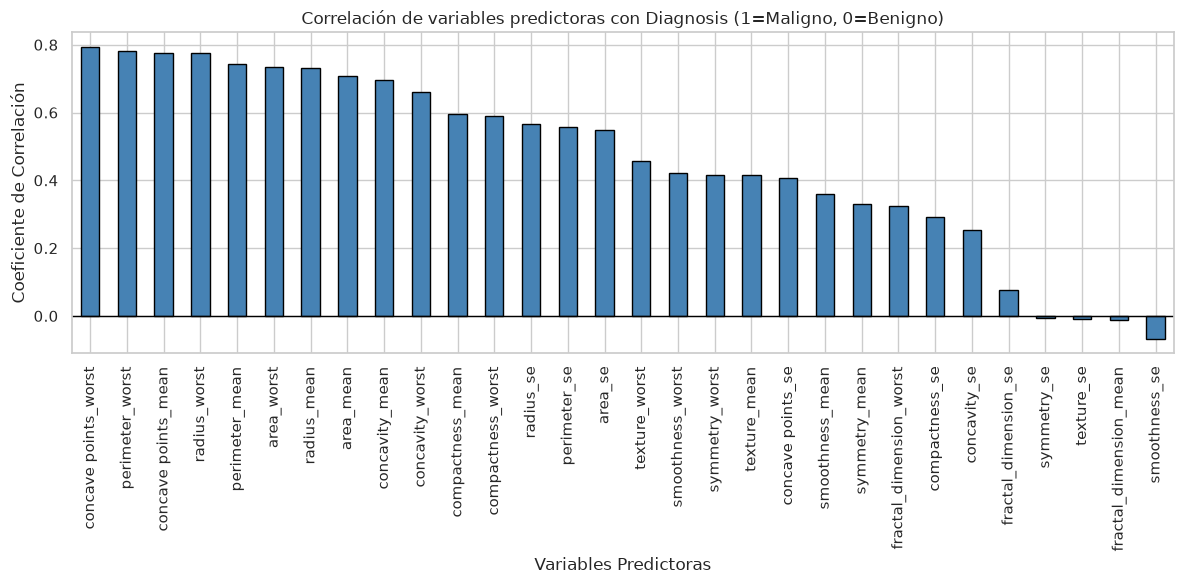

In [169]:
# 5.Visualización gráfica de la correlación de las variables predictoras
plt.figure(figsize=(12, 6))
# Se excluye la propia variable 'diagnosis' (que tendría correlación 1.0) para el gráfico
correlacion_diagnosis.drop('diagnosis').plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Correlación de variables predictoras con Diagnosis (1=Maligno, 0=Benigno)')
plt.ylabel('Coeficiente de Correlación')
plt.xlabel('Variables Predictoras')
plt.xticks(rotation=90)
plt.axhline(0, color='black', linewidth=1)
plt.tight_layout()
plt.show()

Se logra observar que la gran mayoria de columnas tienen correlación con el target, pero hay algunas que tienen negativa, igualemnte son muy pocas para influir significativamente, ademas el dataset presenta indicios de multicolinealidad debido a los multiples variables que miden la celula


Matriz de Correlación:
                         diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  smoothness_mean  compactness_mean  concavity_mean  \
diagnosis                 1.000000     0.730029      0.415185        0.742636   0.708984         0.358560          0.596534        0.696360   
radius_mean               0.730029     1.000000      0.323782        0.997855   0.987357         0.170581          0.506124        0.676764   
texture_mean              0.415185     0.323782      1.000000        0.329533   0.321086        -0.023389          0.236702        0.302418   
perimeter_mean            0.742636     0.997855      0.329533        1.000000   0.986507         0.207278          0.556936        0.716136   
area_mean                 0.708984     0.987357      0.321086        0.986507   1.000000         0.177028          0.498502        0.685983   
smoothness_mean           0.358560     0.170581     -0.023389        0.207278   0.177028         1.000000          0.6

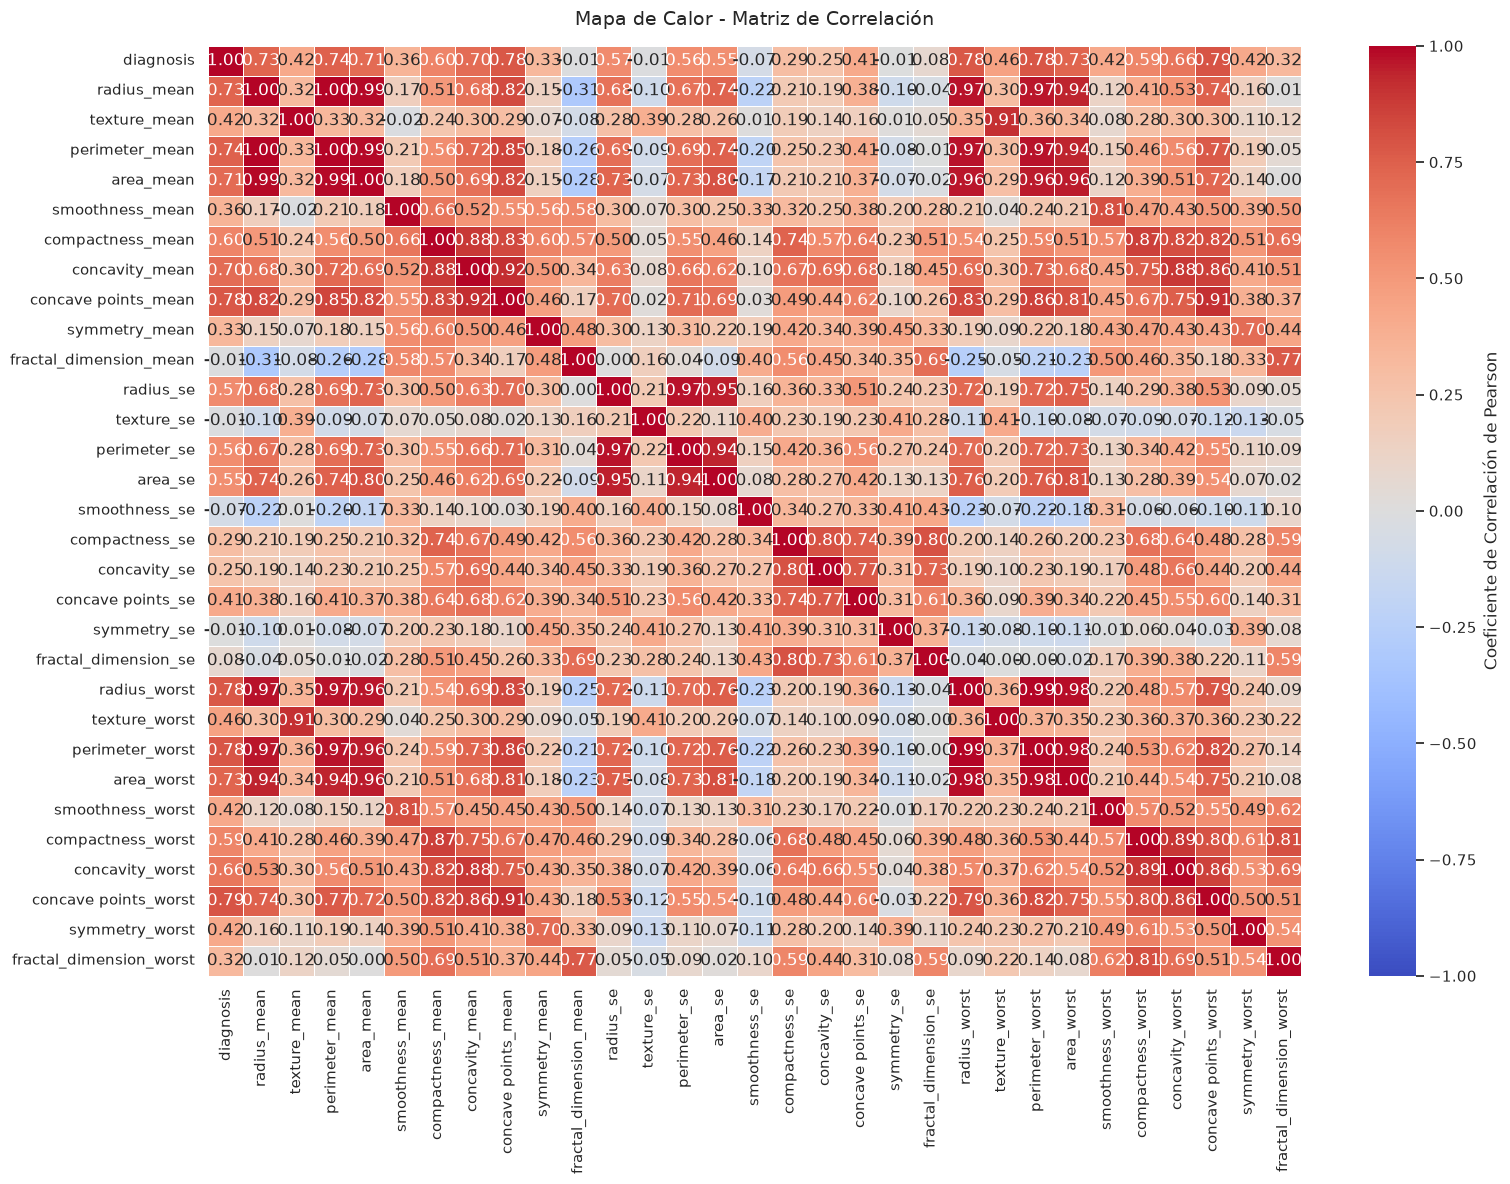

In [170]:
matriz_correlacion = df_breast_copia.corr()

# Mostramos la matriz en texto (opcional)
print("\nMatriz de Correlación:")
print(matriz_correlacion)

# Generamos el mapa de calor (Heatmap)
plt.figure(figsize=(16, 12))
sns.heatmap(
    matriz_correlacion, 
    annot=True,          # Muestra el valor numérico en cada celda
    fmt=".2f",           # Limita a 2 decimales para que sea legible
    cmap='coolwarm',     # Gradiente de azul (negativo) a rojo (positivo)
    vmin=-1, vmax=1,     # Escala de correlación estandarizada
    linewidths=0.5, 
    cbar_kws={'label': 'Coeficiente de Correlación de Pearson'}
)

plt.title('Mapa de Calor - Matriz de Correlación', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

# Analisis de valores Outliers

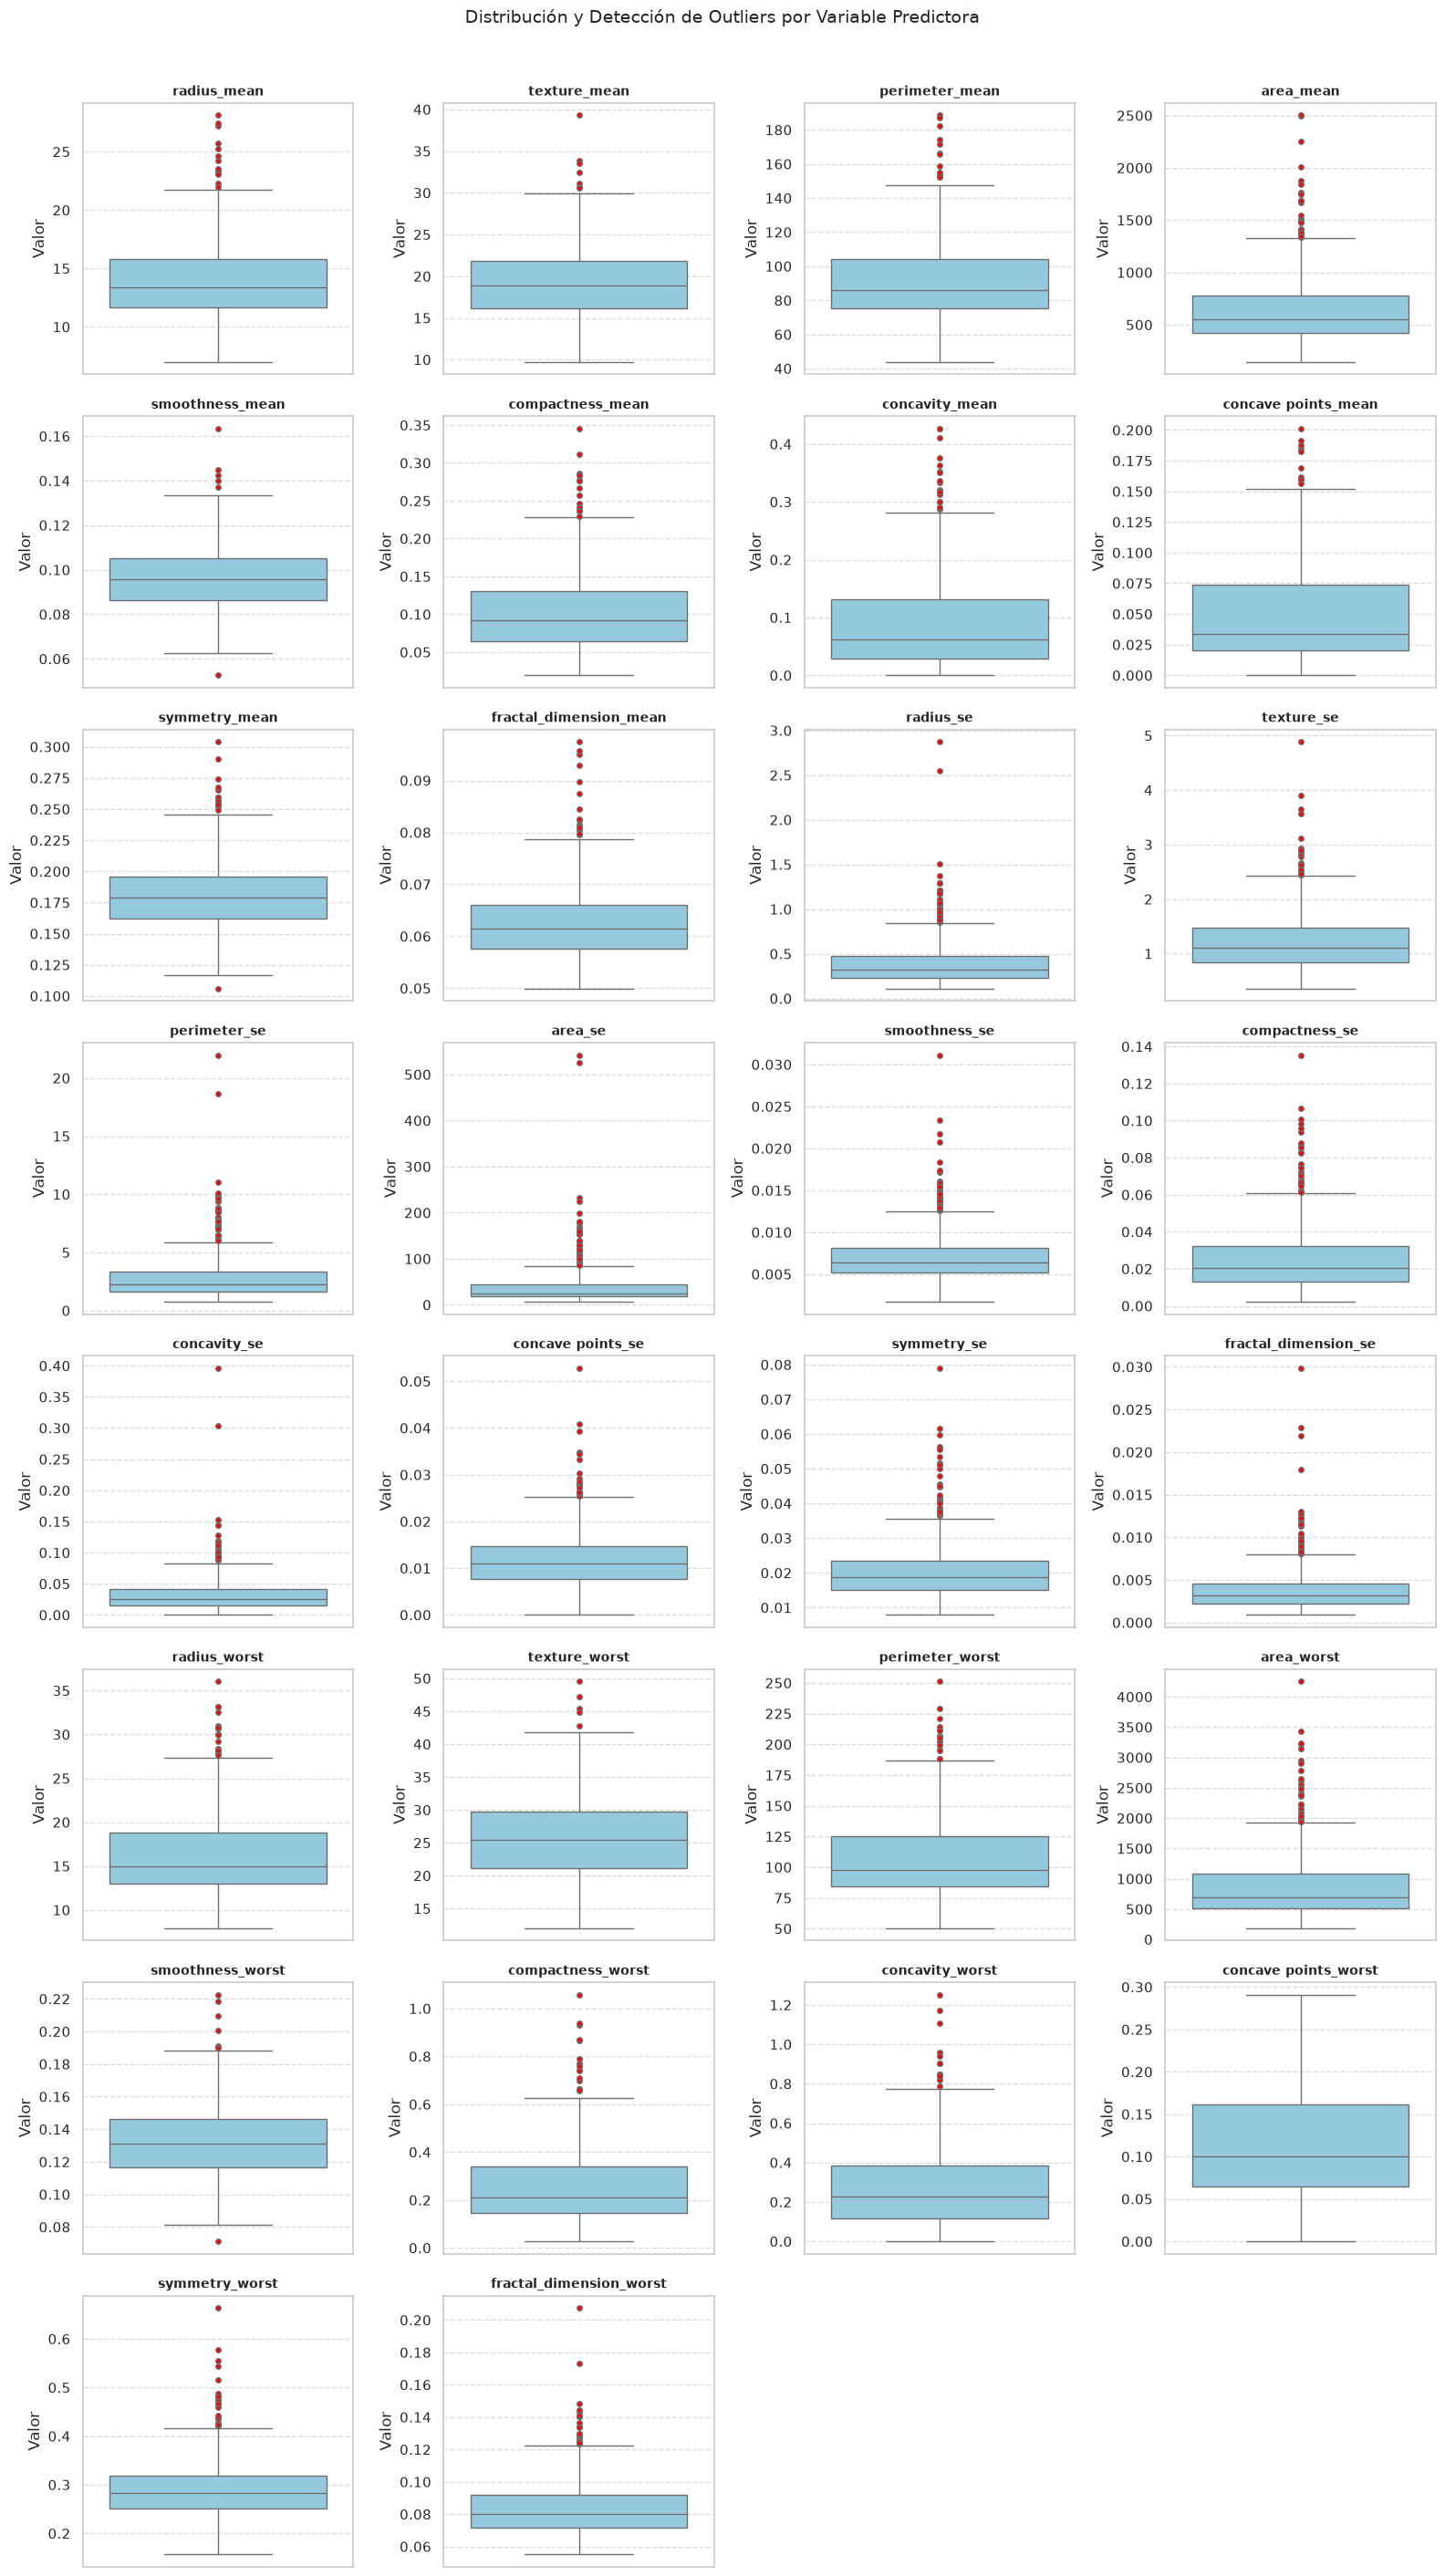

In [171]:
# Aislamos las variables pred
columnas_predictoras = [col for col in df_limpio.columns if col != 'diagnosis']

# 2. config cuadriculas
n_cols = 4  # 4 gráficos por fila
n_rows = math.ceil(len(columnas_predictoras) / n_cols)

plt.figure(figsize=(16, n_rows * 3.5))

# boxplot config
for i, col in enumerate(columnas_predictoras, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(y=df_limpio[col], color='skyblue', flierprops={'marker': 'o', 'markersize': 4, 'markerfacecolor': 'red'})
    plt.title(col, fontsize=10, fontweight='bold')
    plt.ylabel('Valor')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.suptitle('Distribución y Detección de Outliers por Variable Predictora', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

Como se logra visualizar hay registro de outliers, pero los outliers presentan la aparicion de células malignas, por ende no se pueden eliminar tales registros, porque o si no haria que se disminuya significativamente el dataset. **Se toma la decision de dejar el data set intacto en esta area**

# Comparacion de los data sets (limpio/original)

Verificamos las **columnas** eliminadas (la variable shape[1] cuenta columnas, no filas)

In [172]:
print(f"Cantidad de filas original {df_breast.shape[1]}")
print(f"Cantidad de filas en el dataset limpio {df_limpio.shape[1]}")
print(f"Cantidad de filas eliminadas {df_breast.shape[1] - df_limpio.shape[1]}")

Cantidad de filas original 32
Cantidad de filas en el dataset limpio 31
Cantidad de filas eliminadas 1


# Particionamiento entrenamiento y validacion

Para entrenar el modelo separaremos los datos, como estandar se tiende a usar un 20 por ciento de los datos para las pruebas. Con Random State hacemos que los datos vayan cambiando, pero el 42 siempre sera la misma proporcion. Con stratify hacemos que los datos mantengan la misma proporcion en la variable target y no se dispersen de manera aleatoria

In [173]:

X = df_limpio.drop(columns=['diagnosis'])
y = df_limpio['diagnosis']

# Partición: 80% entrenamiento y 20% prueba con estratificación (mantiene proporciones de clases)
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, #Tamanio de la prueba (20%)
    random_state=42, 
    stratify=y
)

Procedemos a mostrar como quedaron las pruebas y test de X y Y 

In [174]:

print(f"Cantidad de registros para X_train : {len(X_train)}")
X_train.head()

Cantidad de registros para X_train : 455


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
10,16.02,23.24,102.70,797.8,0.08206,0.06669,0.03299,0.03323,0.1528,0.05697,0.3795,1.1870,2.466,40.51,0.004029,0.009269,0.01101,0.007591,0.01460,0.003042,19.19,33.88,123.80,1150.0,0.11810,0.1551,0.1459,0.09975,0.2948,0.08452
170,12.32,12.39,78.85,464.1,0.10280,0.06981,0.03987,0.03700,0.1959,0.05955,0.2360,0.6656,1.670,17.43,0.008045,0.011800,0.01683,0.012410,0.01924,0.002248,13.50,15.64,86.97,549.1,0.13850,0.1266,0.1242,0.09391,0.2827,0.06771
407,12.85,21.37,82.63,514.5,0.07551,0.08316,0.06126,0.01867,0.1580,0.06114,0.4993,1.7980,2.552,41.24,0.006011,0.044800,0.05175,0.013410,0.02669,0.007731,14.40,27.01,91.63,645.8,0.09402,0.1936,0.1838,0.05601,0.2488,0.08151
430,14.90,22.53,102.10,685.0,0.09947,0.22250,0.27330,0.09711,0.2041,0.06898,0.2530,0.8749,3.466,24.19,0.006965,0.062130,0.07926,0.022340,0.01499,0.005784,16.35,27.57,125.40,832.7,0.14190,0.7090,0.9019,0.24750,0.2866,0.11550
27,18.61,20.25,122.10,1094.0,0.09440,0.10660,0.14900,0.07731,0.1697,0.05699,0.8529,1.8490,5.632,93.54,0.010750,0.027220,0.05081,0.019110,0.02293,0.004217,21.31,27.26,139.90,1403.0,0.13380,0.2117,0.3446,0.14900,0.2341,0.07421


In [175]:

print(f"Cantidad de registros para X_test : {len(X_test)}")
X_test.head()

Cantidad de registros para X_test : 114


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
120,11.41,10.82,73.34,403.3,0.09373,0.06685,0.03512,0.02623,0.1667,0.06113,0.1408,0.4607,1.103,10.50,0.006040,0.01529,0.015140,0.006460,0.01344,0.002206,12.82,15.97,83.74,510.5,0.1548,0.2390,0.21020,0.08958,0.3016,0.08523
250,20.94,23.56,138.90,1364.0,0.10070,0.16060,0.27120,0.13100,0.2205,0.05898,1.0040,0.8208,6.372,137.90,0.005283,0.03908,0.095180,0.018640,0.02401,0.005002,25.58,27.00,165.30,2010.0,0.1211,0.3172,0.69910,0.21050,0.3126,0.07849
375,16.17,16.07,106.30,788.5,0.09880,0.14380,0.06651,0.05397,0.1990,0.06572,0.1745,0.4890,1.349,14.91,0.004510,0.01812,0.019510,0.011960,0.01934,0.003696,16.97,19.14,113.10,861.5,0.1235,0.2550,0.21140,0.12510,0.3153,0.08960
99,14.42,19.77,94.48,642.5,0.09752,0.11410,0.09388,0.05839,0.1879,0.06390,0.2895,1.8510,2.376,26.85,0.008005,0.02895,0.033210,0.014240,0.01462,0.004452,16.33,30.86,109.50,826.4,0.1431,0.3026,0.31940,0.15650,0.2718,0.09353
455,13.38,30.72,86.34,557.2,0.09245,0.07426,0.02819,0.03264,0.1375,0.06016,0.3408,1.9240,2.287,28.93,0.005841,0.01246,0.007936,0.009128,0.01564,0.002985,15.05,41.61,96.69,705.6,0.1172,0.1421,0.07003,0.07763,0.2196,0.07675


Ahora procedemos a ver como estan los datos con Y.
Y_test : 

In [176]:
print(f"Catidad de registros para y_test {len(y_test)}")
y_test.head()

Catidad de registros para y_test 114


120    0
250    1
375    0
99     1
455    0
Name: diagnosis, dtype: int64

In [177]:
print(f"Cantidad de registron para y_train: {len(y_train)}")
y_train.head()

Cantidad de registron para y_train: 455


10     1
170    0
407    0
430    1
27     1
Name: diagnosis, dtype: int64

Se ha logrado visualizar y comprobar que los datos han sido exitosamente separados para entrenamiento y prueba

### Primeros diez valores de los conjuntos de entrenamiento y prueba

In [178]:
print("Primeros 10 valores de X_train:")
X_train.head(10)

Primeros 10 valores de X_train:


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
10,16.02,23.24,102.70,797.8,0.08206,0.06669,0.03299,0.03323,0.1528,0.05697,0.3795,1.1870,2.466,40.51,0.004029,0.009269,0.01101,0.007591,0.01460,0.003042,19.19,33.88,123.80,1150.0,0.11810,0.1551,0.1459,0.09975,0.2948,0.08452
170,12.32,12.39,78.85,464.1,0.10280,0.06981,0.03987,0.03700,0.1959,0.05955,0.2360,0.6656,1.670,17.43,0.008045,0.011800,0.01683,0.012410,0.01924,0.002248,13.50,15.64,86.97,549.1,0.13850,0.1266,0.1242,0.09391,0.2827,0.06771
407,12.85,21.37,82.63,514.5,0.07551,0.08316,0.06126,0.01867,0.1580,0.06114,0.4993,1.7980,2.552,41.24,0.006011,0.044800,0.05175,0.013410,0.02669,0.007731,14.40,27.01,91.63,645.8,0.09402,0.1936,0.1838,0.05601,0.2488,0.08151
430,14.90,22.53,102.10,685.0,0.09947,0.22250,0.27330,0.09711,0.2041,0.06898,0.2530,0.8749,3.466,24.19,0.006965,0.062130,0.07926,0.022340,0.01499,0.005784,16.35,27.57,125.40,832.7,0.14190,0.7090,0.9019,0.24750,0.2866,0.11550
27,18.61,20.25,122.10,1094.0,0.09440,0.10660,0.14900,0.07731,0.1697,0.05699,0.8529,1.8490,5.632,93.54,0.010750,0.027220,0.05081,0.019110,0.02293,0.004217,21.31,27.26,139.90,1403.0,0.13380,0.2117,0.3446,0.14900,0.2341,0.07421
212,28.11,18.47,188.50,2499.0,0.11420,0.15160,0.32010,0.15950,0.1648,0.05525,2.8730,1.4760,21.980,525.60,0.013450,0.027720,0.06389,0.014070,0.04783,0.004476,28.11,18.47,188.50,2499.0,0.11420,0.1516,0.3201,0.15950,0.1648,0.05525
84,12.00,15.65,76.95,443.3,0.09723,0.07165,0.04151,0.01863,0.2079,0.05968,0.2271,1.2550,1.441,16.16,0.005969,0.018120,0.02007,0.007027,0.01972,0.002607,13.67,24.90,87.78,567.9,0.13770,0.2003,0.2267,0.07632,0.3379,0.07924
36,14.25,21.72,93.63,633.0,0.09823,0.10980,0.13190,0.05598,0.1885,0.06125,0.2860,1.0190,2.657,24.91,0.005878,0.029950,0.04815,0.011610,0.02028,0.004022,15.89,30.36,116.20,799.6,0.14460,0.4238,0.5186,0.14470,0.3591,0.10140
171,13.43,19.63,85.84,565.4,0.09048,0.06288,0.05858,0.03438,0.1598,0.05671,0.4697,1.1470,3.142,43.40,0.006003,0.010630,0.02151,0.009443,0.01520,0.001868,17.98,29.87,116.60,993.6,0.14010,0.1546,0.2644,0.11600,0.2884,0.07371
237,20.48,21.46,132.50,1306.0,0.08355,0.08348,0.09042,0.06022,0.1467,0.05177,0.6874,1.0410,5.144,83.50,0.007959,0.031330,0.04257,0.016710,0.01341,0.003933,24.22,26.17,161.70,1750.0,0.12280,0.2311,0.3158,0.14450,0.2238,0.07127


In [179]:
print("Primeros 10 valores de X_test:")
X_test.head(10)

Primeros 10 valores de X_test:


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
120,11.410,10.82,73.34,403.3,0.09373,0.06685,0.03512,0.02623,0.1667,0.06113,0.1408,0.4607,1.103,10.50,0.006040,0.01529,0.015140,0.006460,0.01344,0.002206,12.82,15.97,83.74,510.5,0.1548,0.2390,0.21020,0.08958,0.3016,0.08523
250,20.940,23.56,138.90,1364.0,0.10070,0.16060,0.27120,0.13100,0.2205,0.05898,1.0040,0.8208,6.372,137.90,0.005283,0.03908,0.095180,0.018640,0.02401,0.005002,25.58,27.00,165.30,2010.0,0.1211,0.3172,0.69910,0.21050,0.3126,0.07849
375,16.170,16.07,106.30,788.5,0.09880,0.14380,0.06651,0.05397,0.1990,0.06572,0.1745,0.4890,1.349,14.91,0.004510,0.01812,0.019510,0.011960,0.01934,0.003696,16.97,19.14,113.10,861.5,0.1235,0.2550,0.21140,0.12510,0.3153,0.08960
99,14.420,19.77,94.48,642.5,0.09752,0.11410,0.09388,0.05839,0.1879,0.06390,0.2895,1.8510,2.376,26.85,0.008005,0.02895,0.033210,0.014240,0.01462,0.004452,16.33,30.86,109.50,826.4,0.1431,0.3026,0.31940,0.15650,0.2718,0.09353
455,13.380,30.72,86.34,557.2,0.09245,0.07426,0.02819,0.03264,0.1375,0.06016,0.3408,1.9240,2.287,28.93,0.005841,0.01246,0.007936,0.009128,0.01564,0.002985,15.05,41.61,96.69,705.6,0.1172,0.1421,0.07003,0.07763,0.2196,0.07675
318,9.042,18.90,60.07,244.5,0.09968,0.19720,0.19750,0.04908,0.2330,0.08743,0.4653,1.9110,3.769,24.20,0.009845,0.06590,0.102700,0.025270,0.03491,0.007877,10.06,23.40,68.62,297.1,0.1221,0.3748,0.46090,0.11450,0.3135,0.10550
39,13.480,20.82,88.40,559.2,0.10160,0.12550,0.10630,0.05439,0.1720,0.06419,0.2130,0.5914,1.545,18.52,0.005367,0.02239,0.030490,0.012620,0.01377,0.003187,15.53,26.02,107.30,740.4,0.1610,0.4225,0.50300,0.22580,0.2807,0.10710
371,15.190,13.21,97.65,711.8,0.07963,0.06934,0.03393,0.02657,0.1721,0.05544,0.1783,0.4125,1.338,17.72,0.005012,0.01485,0.015510,0.009155,0.01647,0.001767,16.20,15.73,104.50,819.1,0.1126,0.1737,0.13620,0.08178,0.2487,0.06766
98,11.600,12.84,74.34,412.6,0.08983,0.07525,0.04196,0.03350,0.1620,0.06582,0.2315,0.5391,1.475,15.75,0.006153,0.01330,0.016930,0.006884,0.01651,0.002551,13.06,17.16,82.96,512.5,0.1431,0.1851,0.19220,0.08449,0.2772,0.08756
502,12.540,16.32,81.25,476.3,0.11580,0.10850,0.05928,0.03279,0.1943,0.06612,0.2577,1.0950,1.566,18.49,0.009702,0.01567,0.025750,0.011610,0.02801,0.002480,13.57,21.40,86.67,552.0,0.1580,0.1751,0.18890,0.08411,0.3155,0.07538


In [180]:
print("Primeros 10 valores de y_train:")
y_train.head(10)

Primeros 10 valores de y_train:


10     1
170    0
407    0
430    1
27     1
212    1
84     0
36     1
171    1
237    1
Name: diagnosis, dtype: int64

In [181]:
print("Primeros 10 valores de y_test:")
y_test.head(10)

Primeros 10 valores de y_test:


120    0
250    1
375    0
99     1
455    0
318    0
39     1
371    0
98     0
502    0
Name: diagnosis, dtype: int64

# Evaluacion sobre escalar los datos

Procedemos a ver si es necesario escalar los datos en caso de las magnitudes de las variables seas disimiles

In [182]:
# Generamos la tabla descriptiva transpuesta (.T) para facilitar la lectura
resumen_escalas = X_train.describe().T[['min', 'mean', 'std', 'max']]

# Renombramos para claridad
resumen_escalas.columns = ['Mínimo', 'Media', 'Desv. Estándar', 'Máximo']
print(resumen_escalas)

                             Mínimo       Media  Desv. Estándar      Máximo
radius_mean                6.981000   14.166077        3.579081    28.11000
texture_mean               9.710000   19.417692        4.290653    39.28000
perimeter_mean            43.790000   92.215868       24.717118   188.50000
area_mean                143.500000  659.578242      360.418686  2501.00000
smoothness_mean            0.062510    0.095993        0.014310     0.16340
compactness_mean           0.019380    0.103835        0.053910     0.34540
concavity_mean             0.000000    0.089184        0.081698     0.42680
concave points_mean        0.000000    0.049015        0.039686     0.20120
symmetry_mean              0.106000    0.181497        0.027646     0.30400
fractal_dimension_mean     0.050240    0.062715        0.006971     0.09744
radius_se                  0.111500    0.411187        0.290183     2.87300
texture_se                 0.360200    1.217882        0.552312     4.88500
perimeter_se

Procedemos a verlo de manera gráfica

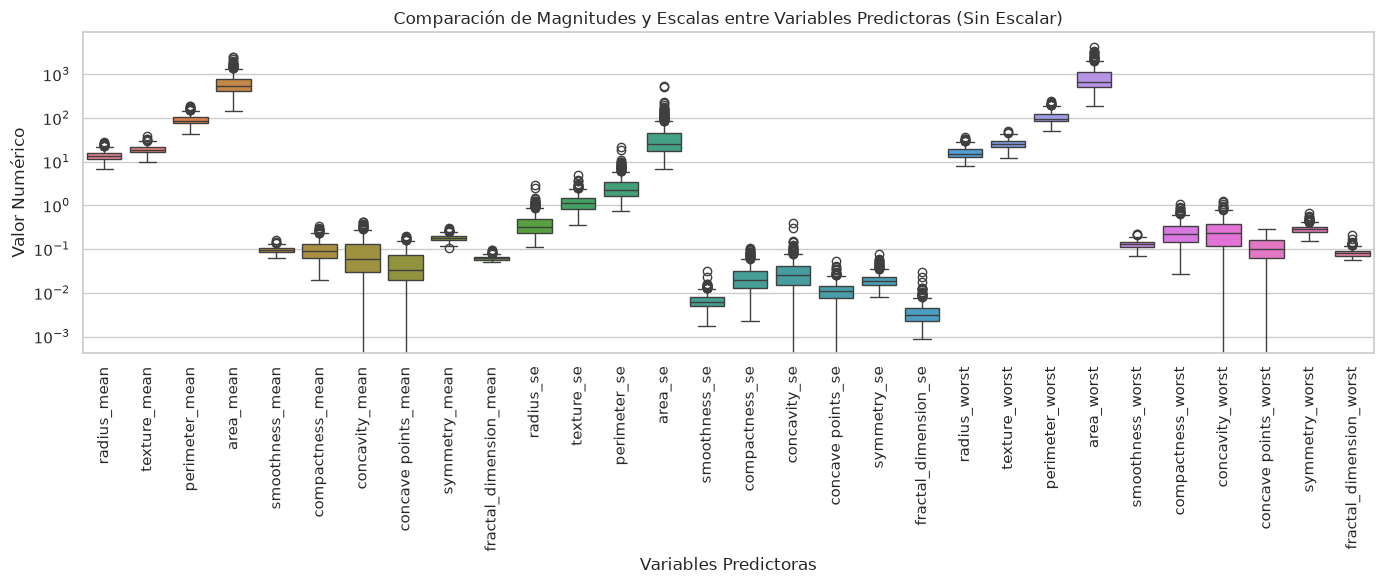

In [183]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=X_train)
plt.xticks(rotation=90)
plt.title('Comparación de Magnitudes y Escalas entre Variables Predictoras (Sin Escalar)')
plt.ylabel('Valor Numérico')
plt.xlabel('Variables Predictoras')
plt.yscale('log')  # Escala logarítmica para evidenciar que abarcan varios órdenes de magnitud
plt.tight_layout()
plt.show()

Se logra visualizar de que hay variables con una mayor magnitud, para que el modelo no tenga una "preferencia" o carga hacia alguna variable **es necesario escalar para prevenir que el modelo tenga sesgos**

# Escalamiento de los datos

Se procede a aplicar el MinMaxScaler()

In [184]:
# 3. Escalado correcto (DESPUÉS de separar)
scaler = MinMaxScaler()

# Se calcula el min/max SOLO con el conjunto de entrenamiento y se transforma
X_train_scaled = scaler.fit_transform(X_train)

# Se transforma el conjunto de prueba usando el min/max aprendido de X_train (sin volver a calcular .fit)
X_test_scaled = scaler.transform(X_test)

In [185]:
X_train_scaled[0]

array([0.42780065, 0.45755834, 0.40709004, 0.27753977, 0.1937754 ,
       0.1451138 , 0.07729616, 0.16515905, 0.23636364, 0.14258475,
       0.09704871, 0.18272631, 0.08052584, 0.06295877, 0.07872999,
       0.06737527, 0.02780303, 0.14379617, 0.09452918, 0.07418156,
       0.40056919, 0.5826226 , 0.36550625, 0.23712151, 0.30991217,
       0.1240019 , 0.11653355, 0.34278351, 0.27261975, 0.19336219])

In [186]:
X_test_scaled[0]

array([0.20961711, 0.03753805, 0.20420151, 0.11020148, 0.30944593,
       0.14560456, 0.08228679, 0.13036779, 0.30656566, 0.23072034,
       0.01061018, 0.02221093, 0.01630307, 0.00690701, 0.14709182,
       0.12518723, 0.03823232, 0.12237166, 0.07820679, 0.04529939,
       0.17395945, 0.10527719, 0.16599432, 0.07994986, 0.55226837,
       0.2054021 , 0.16789137, 0.30783505, 0.28602405, 0.19801915])

### Verificacion del desbalance de clases

El dataset presenta un **desbalance moderado**: 62,74% de los casos son benignos (0) y 37,26% malignos (1), una razon de 1,68:1. Para que este desbalance no afecte el entrenamiento, se utilizo `stratify=y` en la particion, manteniendo la proporcion de clases en ambos conjuntos.

Como tecnica de balanceo adicional, se entrena y evalua una Regresion Logistica con `class_weight='balanced'`, que asigna mayor peso a la clase minoritaria durante el entrenamiento:

In [187]:
modelo_bal = LogisticRegression(solver="lbfgs", max_iter=1000, random_state=42, class_weight="balanced")
modelo_bal.fit(X_train_scaled, y_train)

y_pred_bal = modelo_bal.predict(X_test_scaled)
print("Classification Report — Regresion Logistica con class_weight='balanced':")
print(classification_report(y_test, y_pred_bal, target_names=["Benigno (0)", "Maligno (1)"], digits=4))

cm_bal = confusion_matrix(y_test, y_pred_bal)
print(f"Falsos negativos (cancer no detectado): {cm_bal[1, 0]} | Falsos positivos: {cm_bal[0, 1]}")

Classification Report — Regresion Logistica con class_weight='balanced':
              precision    recall  f1-score   support

 Benigno (0)     0.9730    1.0000    0.9863        72
 Maligno (1)     1.0000    0.9524    0.9756        42

    accuracy                         0.9825       114
   macro avg     0.9865    0.9762    0.9810       114
weighted avg     0.9829    0.9825    0.9824       114

Falsos negativos (cancer no detectado): 2 | Falsos positivos: 0


**Justificacion:** el modelo con `class_weight='balanced'` aumenta el recall de la clase maligna (de 92,86% a 95,24%, reduciendo los falsos negativos de 3 a 2) y la exactitud global (de 97,37% a 98,25%), sin generar falsos positivos. Dado que el contexto oncologico penaliza sobre todo los falsos negativos (cancer no detectado), se considera esta variante como la opcion preferente, y se incluye en la tabla comparativa final del Caso 2.

# Modelo de regresion logistica

EL modelo de regresion logistica es un tipo de algoritmo de clasificación que predice un resultado discreto o categórico, ideal para nuestro caso de estudio

In [188]:
modelo_logistico = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)

Procedemos a entrenar el modelo

In [189]:
modelo_logistico.fit(X_train_scaled, y_train)

# 3. Confirmación en consola
print("Modelo de Regresión Logística entrenado con éxito.")
print(f"Clases aprendidas por el modelo: {modelo_logistico.classes_}")

Modelo de Regresión Logística entrenado con éxito.
Clases aprendidas por el modelo: [0 1]


Logramos ver que el modelo aprendió las clases 0 y 1, es decir benigno (0) y maligna (1)

## Reporte de clasificacion

In [190]:
#Guardamos los valores de test escalados
y_pred = modelo_logistico.predict(X_test_scaled)


reporte = classification_report(
    y_test, 
    y_pred, 
    target_names=['Benigno (0)', 'Maligno (1)'],
    digits=4
)

print("Classification Report - Regresión Logística:")
print(reporte)

Classification Report - Regresión Logística:
              precision    recall  f1-score   support

 Benigno (0)     0.9600    1.0000    0.9796        72
 Maligno (1)     1.0000    0.9286    0.9630        42

    accuracy                         0.9737       114
   macro avg     0.9800    0.9643    0.9713       114
weighted avg     0.9747    0.9737    0.9735       114



## Interpretacion del reporte de clasificacion

Podemos ver que el modelo fue capaz de predecir correctamente el 96% de los pacientes benignos y el 100% de los pacientes malignos (precision). En cuanto al recall, detectó el 100% de los benignos pero solo el 92.86% de los malignos: los 3 casos malignos no detectados (falsos negativos) se clasificaron como benignos. En ambas categorías el promedio (macro avg) se mantiene sobre el 95% y la exactitud global es 97.37%.

## Verificacion de overfitting

Debido a que los resultados estan demasiado buenos, corroboraremos que no haya sobreajuste o overfitting. para ello comparamos con lo que exactitud en la prueba y en el entrenamiento

In [191]:
y_pred_train = modelo_logistico.predict(X_train_scaled)
acc_train = accuracy_score(y_train, y_pred_train)


y_pred_test = modelo_logistico.predict(X_test_scaled)
acc_test = accuracy_score(y_test, y_pred_test)

print(f"Exactitud en Entrenamiento (Train): {acc_train * 100:.2f}%")
print(f"Exactitud en Prueba (Test):         {acc_test * 100:.2f}%")
print(f"Diferencia (Brecha):                 {abs(acc_train - acc_test) * 100:.2f}%")

Exactitud en Entrenamiento (Train): 96.92%
Exactitud en Prueba (Test):         97.37%
Diferencia (Brecha):                 0.45%


la brecha es muy baja , se descarta posibilidad de sobreajuste

## Matriz de confusion

Procedemos a hacer la matriz de confusion, el cual nos deja ver de una manera mas exacta como es que el modelo fue prediciendo 

In [192]:
matriz_confusion = confusion_matrix(y_test, y_pred)

Grafico de la matriz

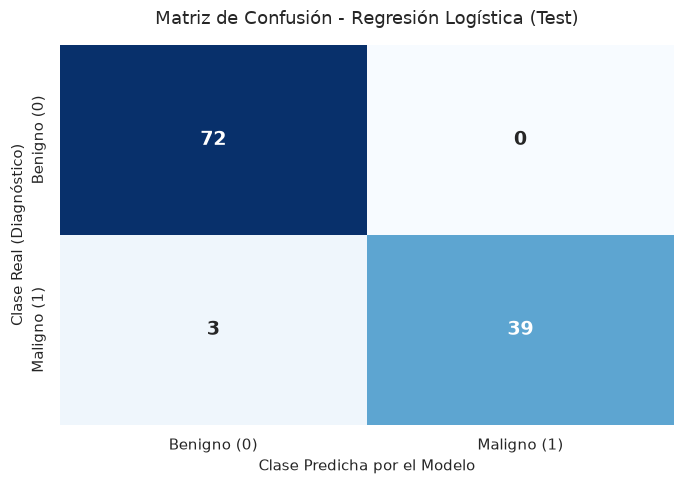

In [193]:
plt.figure(figsize=(7, 5))
sns.heatmap(
    matriz_confusion, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    cbar=False,
    xticklabels=['Benigno (0)', 'Maligno (1)'],
    yticklabels=['Benigno (0)', 'Maligno (1)'],
    annot_kws={'size': 14, 'weight': 'bold'}
)

plt.title('Matriz de Confusión - Regresión Logística (Test)', fontsize=13, pad=15)
plt.xlabel('Clase Predicha por el Modelo', fontsize=11)
plt.ylabel('Clase Real (Diagnóstico)', fontsize=11)
plt.tight_layout()
plt.show()

Generamos un desglose en consola para leer mejor los números

In [194]:
tn_lr, fp_lr, fn_lr, tp_lr = matriz_confusion.ravel()
print(f"Verdaderos Negativos (TN - Benignos correctos): {tn_lr}")
print(f"Falsos Positivos      (FP - Falsa alarma):        {fp_lr}")
print(f"Falsos Negativos      (FN - Cáncer no detectado): {fn_lr}")
print(f"Verdaderos Positivos  (TP - Malignos correctos): {tp_lr}")

Verdaderos Negativos (TN - Benignos correctos): 72
Falsos Positivos      (FP - Falsa alarma):        0
Falsos Negativos      (FN - Cáncer no detectado): 3
Verdaderos Positivos  (TP - Malignos correctos): 39


El modelo se equivoco muy poco: la gran mayoria de las predicciones se concentran en los verdaderos positivos y en los verdaderos negativos. En cuanto a errores, solo tuvo 0 falsos positivos y 3 falsos negativos (cánceres no detectados), un margen de error bajísimo.

## Curva Roc

In [195]:
# vemos las predicciones
y_probs = modelo_logistico.predict_proba(X_test_scaled)[:, 1]

# tasa de falsos positivos y falso negativos
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

auc_score = roc_auc_score(y_test, y_probs)

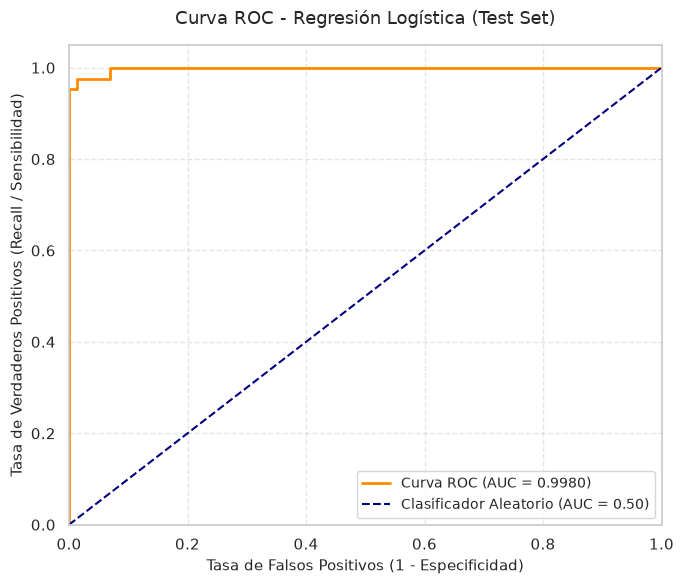

Área Bajo la Curva ROC (AUC): 0.9980


In [196]:
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Clasificador Aleatorio (AUC = 0.50)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)', fontsize=11)
plt.ylabel('Tasa de Verdaderos Positivos (Recall / Sensibilidad)', fontsize=11)
plt.title('Curva ROC - Regresión Logística (Test Set)', fontsize=13, pad=15)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f"Área Bajo la Curva ROC (AUC): {auc_score:.4f}")

Se interpreta que el rendimiento del modelo es muy bueno, esto debido a que la curva ROC se aleja completamente de la aleatoriedad. Si nos fijamos en los números, el área bajo la curva es de 0.9980: cuanto más cerca está de 1, mejor.

# Haciendo uso de la técnica GridSearchCV


**GridSearchCV es una herramienta de optimización de hiperparámetros**  en machine learning que busca de forma exhaustiva la mejor combinación de parámetros para un modelo, utilizando validación cruzada (Cross-Validation).
En un modelo de regresión, su función principal es probar todas las combinaciones posibles de hiperparámetros que tú le indiques y medir cuál de ellas reduce al mínimo el error de predicción o maximiza una métrica de desempeño específica.

In [197]:
#Definicion del de los parametros para GridSearchCV
param_grid = {
    'max_iter': [50, 100, 150, 200],
    'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga']
}

In [198]:
#Configutacion del GridSearchCV

grid_search = GridSearchCV(
    estimator=modelo_logistico,
    param_grid=param_grid, #Aca se guarda la varible de la casilla anterior
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

Para ejecutar la búsqueda , usaremos los datos escalados para no generar sesgos también

In [199]:
grid_search.fit(X_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_iter': [50, 100, ...], 'solver': ['newton-cg', 'lbfgs', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of

## Resultados de GridSearchCV

Procedemos a ver cuales fueron los mejores parámetros 

In [200]:

print("=== Resultados de GridSearchCV ===")
print(f"Mejores hiperparámetros: {grid_search.best_params_}")
print(f"Mejor Accuracy en CV (Train): {grid_search.best_score_ * 100:.2f}%\n")

=== Resultados de GridSearchCV ===
Mejores hiperparámetros: {'max_iter': 50, 'solver': 'newton-cg'}
Mejor Accuracy en CV (Train): 96.26%



Procedemos a entrenar el modelo con la configuracion anterior

In [201]:
mejor_modelo_logistico = grid_search.best_estimator_
y_pred_grid = mejor_modelo_logistico.predict(X_test_scaled)

print("Classification Report con el Mejor Modelo (Test Set):")
print(classification_report(y_test, y_pred_grid, target_names=['Benigno (0)', 'Maligno (1)'], digits=4))

Classification Report con el Mejor Modelo (Test Set):
              precision    recall  f1-score   support

 Benigno (0)     0.9600    1.0000    0.9796        72
 Maligno (1)     1.0000    0.9286    0.9630        42

    accuracy                         0.9737       114
   macro avg     0.9800    0.9643    0.9713       114
weighted avg     0.9747    0.9737    0.9735       114



Podemos ver que los resultados son similares con el modelo sin esta configuracion, entregando valores muy positivos

## Comparacion de modelos con diferentes parametros

Ahora se compara los resultados, para evaluar si es que las metricas difieren significativamente 

In [202]:

#Guardamos los resutlados de ambos modelos
y_pred_base = modelo_logistico.predict(X_test_scaled) #Sin grid
y_pred_grid = mejor_modelo_logistico.predict(X_test_scaled) # Cin grid

Mostramos la metrica del modelo base, osea sin GridSearchCV

In [203]:
print("=" * 65)
print("  MODELO BASE (solver='lbfgs', max_iter=1000)")
print("=" * 65)
print(classification_report(y_test, y_pred_base, target_names=['Benigno (0)', 'Maligno (1)'], digits=4))

  MODELO BASE (solver='lbfgs', max_iter=1000)
              precision    recall  f1-score   support

 Benigno (0)     0.9600    1.0000    0.9796        72
 Maligno (1)     1.0000    0.9286    0.9630        42

    accuracy                         0.9737       114
   macro avg     0.9800    0.9643    0.9713       114
weighted avg     0.9747    0.9737    0.9735       114



Mostramos la metrica del modelo base, osea **con GridSearchCV**

In [204]:
print("=" * 65)
print("  MODELO OPTIMIZADO GridSearchCV (best_estimator_)")
print(f"  Parámetros: {grid_search.best_params_}")
print("=" * 65)
print(classification_report(y_test, y_pred_grid, target_names=['Benigno (0)', 'Maligno (1)'], digits=4))

  MODELO OPTIMIZADO GridSearchCV (best_estimator_)
  Parámetros: {'max_iter': 50, 'solver': 'newton-cg'}
              precision    recall  f1-score   support

 Benigno (0)     0.9600    1.0000    0.9796        72
 Maligno (1)     1.0000    0.9286    0.9630        42

    accuracy                         0.9737       114
   macro avg     0.9800    0.9643    0.9713       114
weighted avg     0.9747    0.9737    0.9735       114



Para tener una mejor visualización generamos una tabla comparativa

In [205]:
acc_base = accuracy_score(y_test, y_pred_base)
acc_grid = accuracy_score(y_test, y_pred_grid)

cm_base = confusion_matrix(y_test, y_pred_base)
cm_grid = confusion_matrix(y_test, y_pred_grid)

# Extracción de Verdaderos Positivos (TP) y Falsos Negativos (FN) de la clase 1 (Maligno)
tp_base, fn_base = cm_base[1, 1], cm_base[1, 0]
tp_grid, fn_grid = cm_grid[1, 1], cm_grid[1, 0]

tabla_comparativa = pd.DataFrame({
    'Métrica': ['Accuracy Global', 'Recall Maligno (1)', 'Falsos Negativos (FN)', 'Verdaderos Positivos (TP)'],
    'Modelo Base (lbfgs)': [f"{acc_base * 100:.2f}%", f"{(tp_base / (tp_base + fn_base)) * 100:.2f}%", fn_base, tp_base],
    'Modelo GridSearchCV': [f"{acc_grid * 100:.2f}%", f"{(tp_grid / (tp_grid + fn_grid)) * 100:.2f}%", fn_grid, tp_grid]
})

tabla_comparativa #Imprimmos los resultados

,Métrica,Modelo Base (lbfgs),Modelo GridSearchCV
0,Accuracy Global,97.37%,97.37%
1,Recall Maligno (1),92.86%,92.86%
2,Falsos Negativos (FN),3,3
3,Verdaderos Positivos (TP),39,39


Podemos ver que entre ambos modelos, tienen resultados identicos. **Se llega a la conclusión que el modelo se mantiene**

# Modelo de arbol de desicion 

Un decision tree es un algoritmo de aprendizaje supervisado no paramétrico, que se utiliza tanto para tareas de clasificación como de regresión. Tiene una estructura jerárquica, de árbol, que consta de un nodo raíz, ramas, nodos internos y nodos de hoja.

In [206]:
#Guardamos el arbol de desicion
arbol_decision = DecisionTreeClassifier(max_depth=3, random_state=0)

In [207]:
arbol_decision.fit(X_train_scaled, y_train)

y_pred_arbol_d3 = arbol_decision.predict(X_test_scaled)

exactitud_arbol_d3 = accuracy_score(y_test, y_pred_arbol_d3)

## Metricas del arbol de desicion

Verificamos la exactitud del modelo

In [208]:

exactitud_arbol_d3 = accuracy_score(y_test, y_pred_arbol_d3)

print("=== Evaluación del Árbol de Decisión ===")
print(f"Precisión global (Accuracy Score): {exactitud_arbol_d3:.4f} ({exactitud_arbol_d3 * 100:.2f}%)")


=== Evaluación del Árbol de Decisión ===
Precisión global (Accuracy Score): 0.9123 (91.23%)


Generamos el reporte de clasificacion para ver con mas detalle

In [209]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred_arbol_d3, target_names=['Benigno (0)', 'Maligno (1)'], digits=4))


Classification Report:
              precision    recall  f1-score   support

 Benigno (0)     0.8974    0.9722    0.9333        72
 Maligno (1)     0.9444    0.8095    0.8718        42

    accuracy                         0.9123       114
   macro avg     0.9209    0.8909    0.9026       114
weighted avg     0.9148    0.9123    0.9107       114



Se logra ver que el modelo tiene problemas acertando algunas células malignas: su recall en la clase Maligno (1) es de 0.8095, es decir, deja escapar cerca de un 19% de los casos reales de cáncer.

# Modelo de arbol de decisión sin restriccion

Se construye el modelo sin profundidad

In [210]:
arbol_decision_sin_rest = DecisionTreeClassifier( random_state=0)

Al igual que con el arbol anterior se va a entrenar, poner a prueba y guardar resultados en la misma casilla

In [211]:
arbol_decision_sin_rest.fit(X_train_scaled, y_train)

y_pred_arbol_libre = arbol_decision_sin_rest.predict(X_test_scaled)

exactitud_arbol_libre = accuracy_score(y_test, y_pred_arbol_libre)

## Metricas de arbol de desicion sin restriccion

In [212]:

exactitud_arbol_libre = accuracy_score(y_test, y_pred_arbol_libre)

print("=== Evaluación del Árbol de Decisión sin rest ===")
print(f"Precisión global (Accuracy Score): {exactitud_arbol_libre:.4f} ({exactitud_arbol_libre * 100:.2f}%)")

=== Evaluación del Árbol de Decisión sin rest ===
Precisión global (Accuracy Score): 0.9298 (92.98%)


Se logra ver que el puntaje en la prueba es un poco mejor que con la restricción de profundidad (92.98% frente a 91.23%), pero la brecha con el entrenamiento es mayor, lo que enciende la sospecha de sobreajuste.

In [213]:
print("\nClassification Report , Sin restriccion: ")
print(classification_report(y_test, y_pred_arbol_libre, target_names=['Benigno (0)', 'Maligno (1)'], digits=4))


Classification Report , Sin restriccion: 
              precision    recall  f1-score   support

 Benigno (0)     0.9444    0.9444    0.9444        72
 Maligno (1)     0.9048    0.9048    0.9048        42

    accuracy                         0.9298       114
   macro avg     0.9246    0.9246    0.9246       114
weighted avg     0.9298    0.9298    0.9298       114



A comparación del modelo anterior con restricción de profundidad, este modelo **mejora en ambas clases**: la precisión en benignos sube de 0.8974 a 0.9444 y el recall en malignos sube de 0.8095 a 0.9048. El trade-off aparece en la mayor brecha entrenamiento-prueba.

## Verificacion de overfitting

Se procede a revisar si ambos modelos presentan overfitting a través de dos métodos. Comparacion de rendimiento en el entrenamiento y en la prueba con la curva de validacion

## Verificacion de exactitud de entrenamiento vs prueba 

In [214]:
# Árbol de decisión CON restricción (max_depth=3)
acc_train = arbol_decision.score(X_train_scaled, y_train)
acc_test = arbol_decision.score(X_test_scaled, y_test)

print("=== Árbol de Decisión CON restricción (max_depth=3) ===")
print(f"Accuracy en Entrenamiento: {acc_train * 100:.2f}%")
print(f"Accuracy en Prueba:        {acc_test * 100:.2f}%")
print(f"Brecha (Diferencia):       {(acc_train - acc_test) * 100:.2f}%")

# Árbol de decisión SIN restricción
acc_train_sin = arbol_decision_sin_rest.score(X_train_scaled, y_train)
acc_test_sin = arbol_decision_sin_rest.score(X_test_scaled, y_test)

print("\n=== Árbol de Decisión SIN restricción ===")
print(f"Accuracy en Entrenamiento: {acc_train_sin * 100:.2f}%")
print(f"Accuracy en Prueba:        {acc_test_sin * 100:.2f}%")
print(f"Brecha (Diferencia):       {(acc_train_sin - acc_test_sin) * 100:.2f}%")

=== Árbol de Decisión CON restricción (max_depth=3) ===
Accuracy en Entrenamiento: 96.70%
Accuracy en Prueba:        91.23%
Brecha (Diferencia):       5.48%

=== Árbol de Decisión SIN restricción ===
Accuracy en Entrenamiento: 100.00%
Accuracy en Prueba:        92.98%
Brecha (Diferencia):       7.02%


En el arbol **con restricción** (max_depth=3), la brecha es de 5.48% (96.70% en entrenamiento vs 91.23% en prueba), lo que indica que no hay un overfitting severo.

En el arbol **sin restricción**, la brecha aumentó a 7.02% y el puntaje en entrenamiento fue perfecto (100% vs 92.98% en prueba), lo que da indicios claros de sobreajuste: el árbol memorizó las particularidades del conjunto de entrenamiento.

Se concluye que el arbol con restricción de profundidad generaliza de forma más estable. Pasamos a visualizar la curva de aprendizaje.

# Verificacion de overfitting con la curva de validacion por profundidad

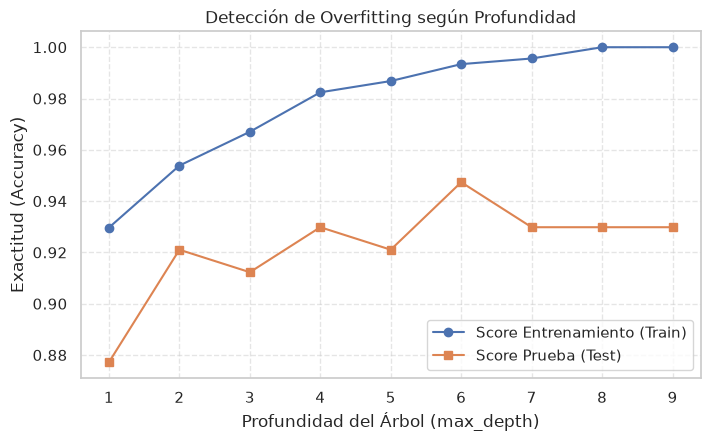

In [215]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier

profundidades = range(1, 10) 
train_scores = []
test_scores = []

for d in profundidades:
    clf = DecisionTreeClassifier(max_depth=d, random_state=0)
    clf.fit(X_train_scaled, y_train)
    train_scores.append(clf.score(X_train_scaled, y_train))
    test_scores.append(clf.score(X_test_scaled, y_test))

plt.figure(figsize=(8, 4.5))
plt.plot(profundidades, train_scores, label='Score Entrenamiento (Train)', marker='o')
plt.plot(profundidades, test_scores, label='Score Prueba (Test)', marker='s')
plt.xlabel('Profundidad del Árbol (max_depth)')
plt.ylabel('Exactitud (Accuracy)')
plt.title('Detección de Overfitting según Profundidad')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

En este grafico se logra visualizar de que solo hay overfitting pasado el limite establecido de profundidad, osea despues del 3. Eso quiere decir que **el arbol sin limite de profundidad tiene o tendra overfitting**

# Grafico de los arboles de desicion 

Procedemos a ver la forma de los arboles generados, los nodos anaranjados corresponden son los casos benignos y azulados malignos

Arbol de desicion con restriccion

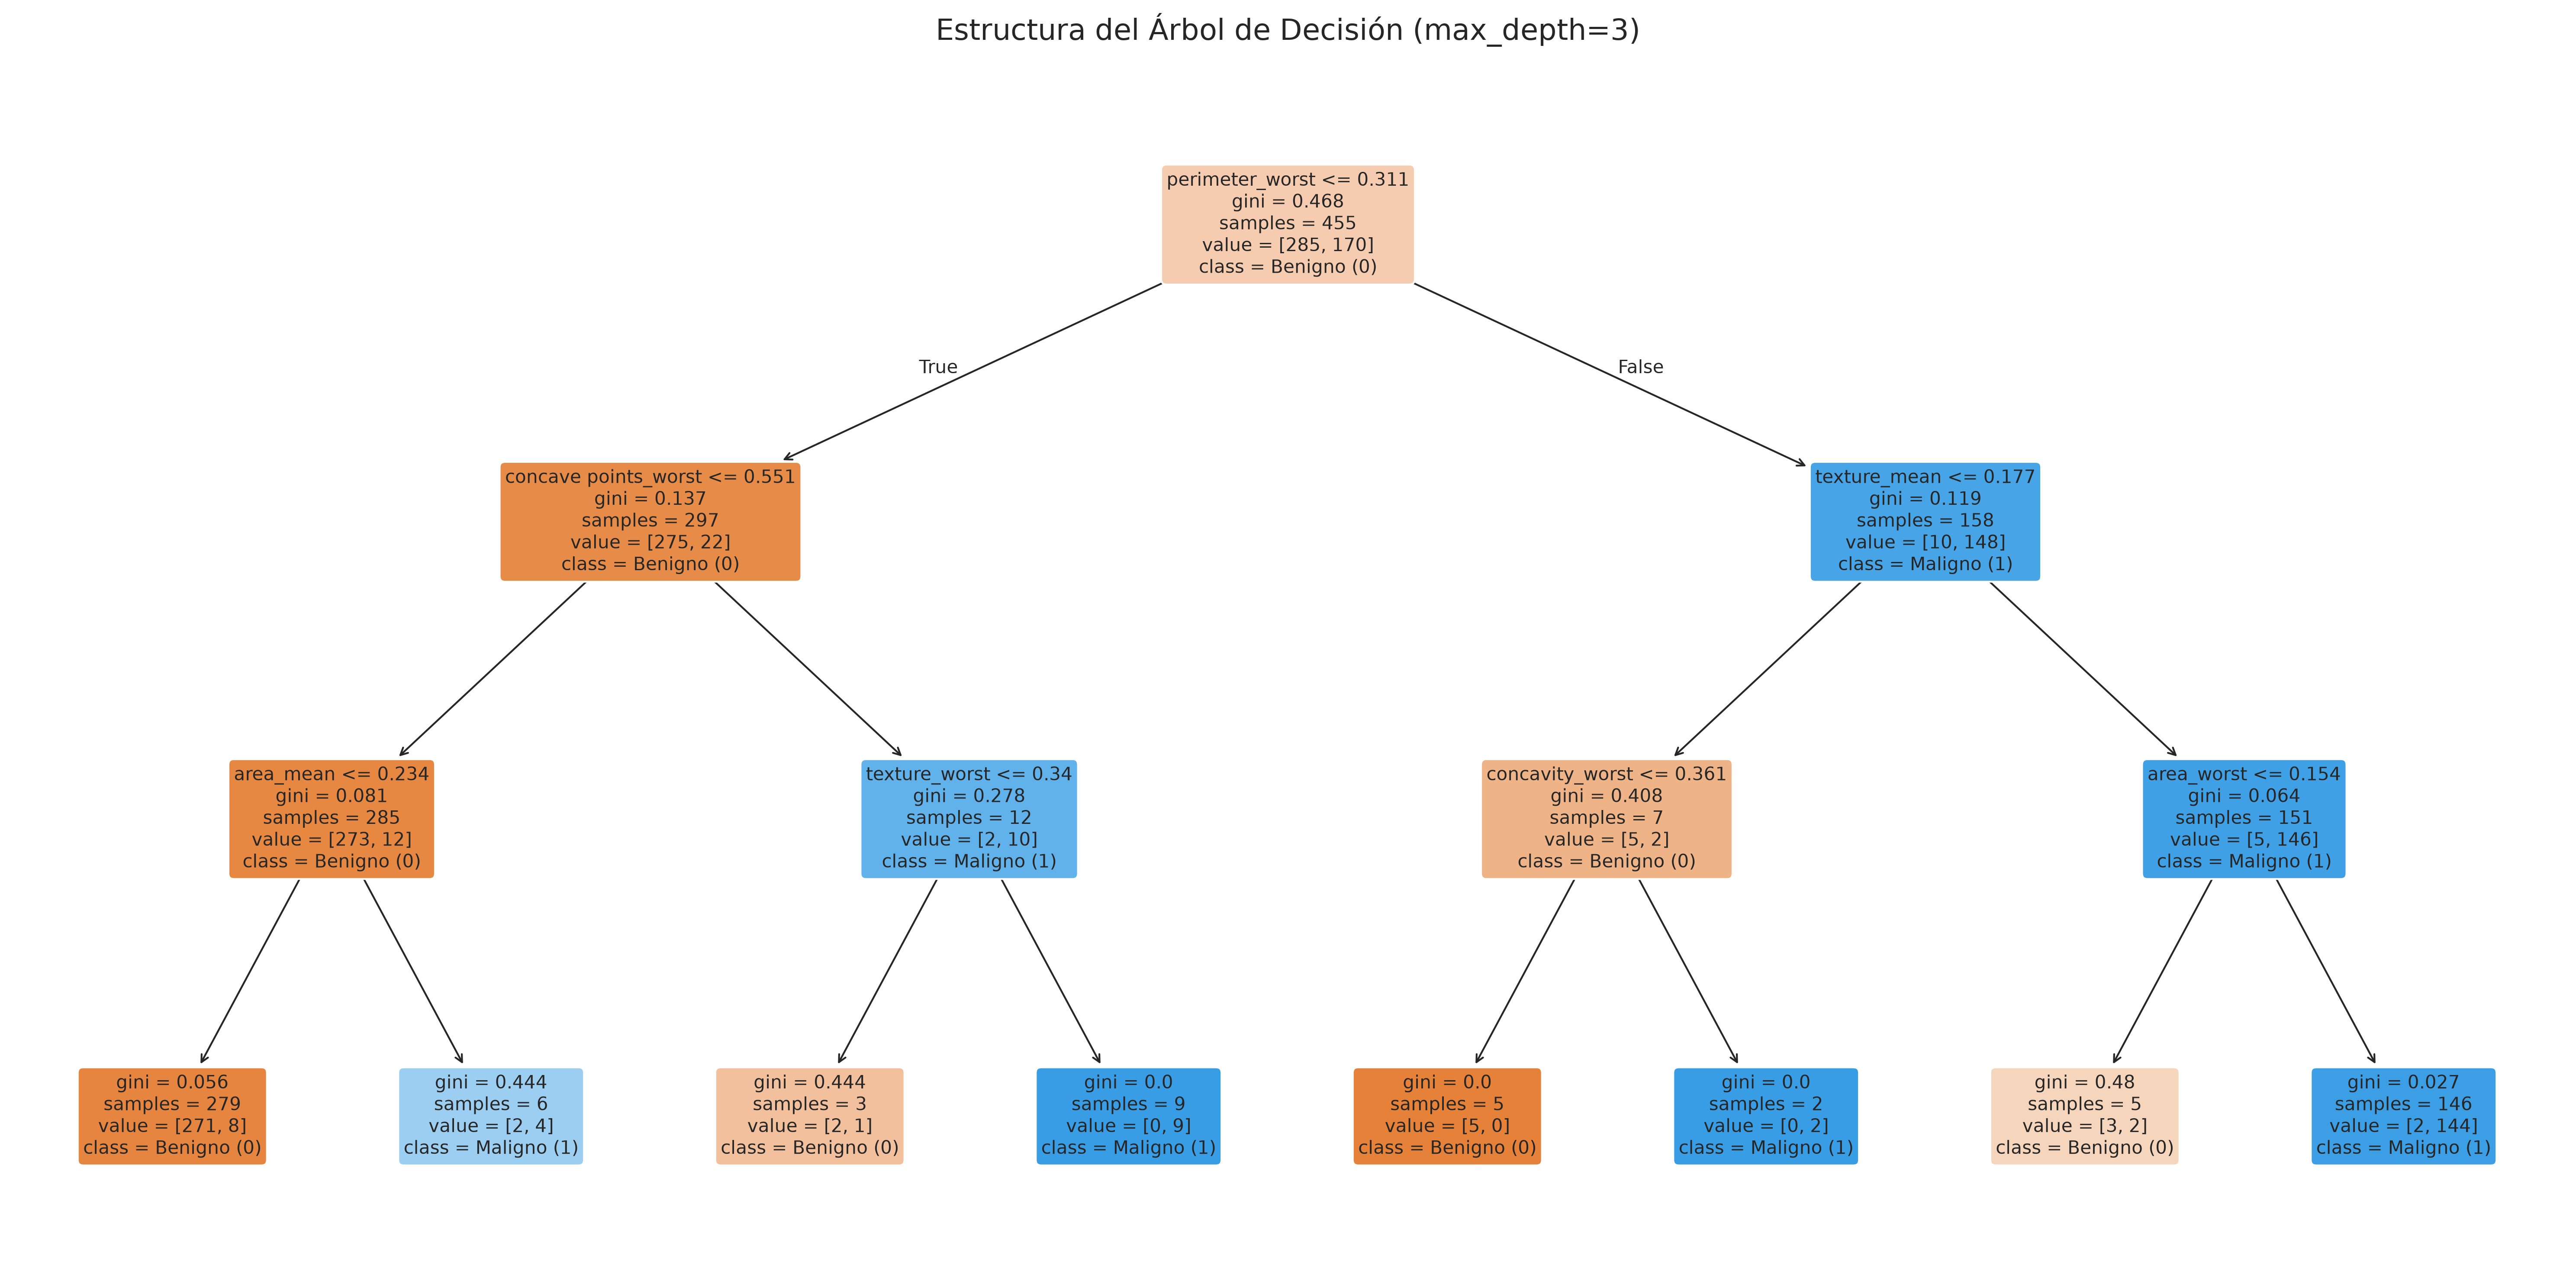

In [216]:
#config
plt.figure(figsize=(20, 10), dpi=300)


plot_tree(
    arbol_decision, #Arbol de desision con rest
    feature_names=X.columns,
    class_names=['Benigno (0)', 'Maligno (1)'],
    filled=True,
    rounded=True,
    fontsize=10,
    precision=3
)

plt.title("Estructura del Árbol de Decisión (max_depth=3)", fontsize=16, pad=20)
plt.tight_layout()
plt.show()

arbol de decisión sin restriccion

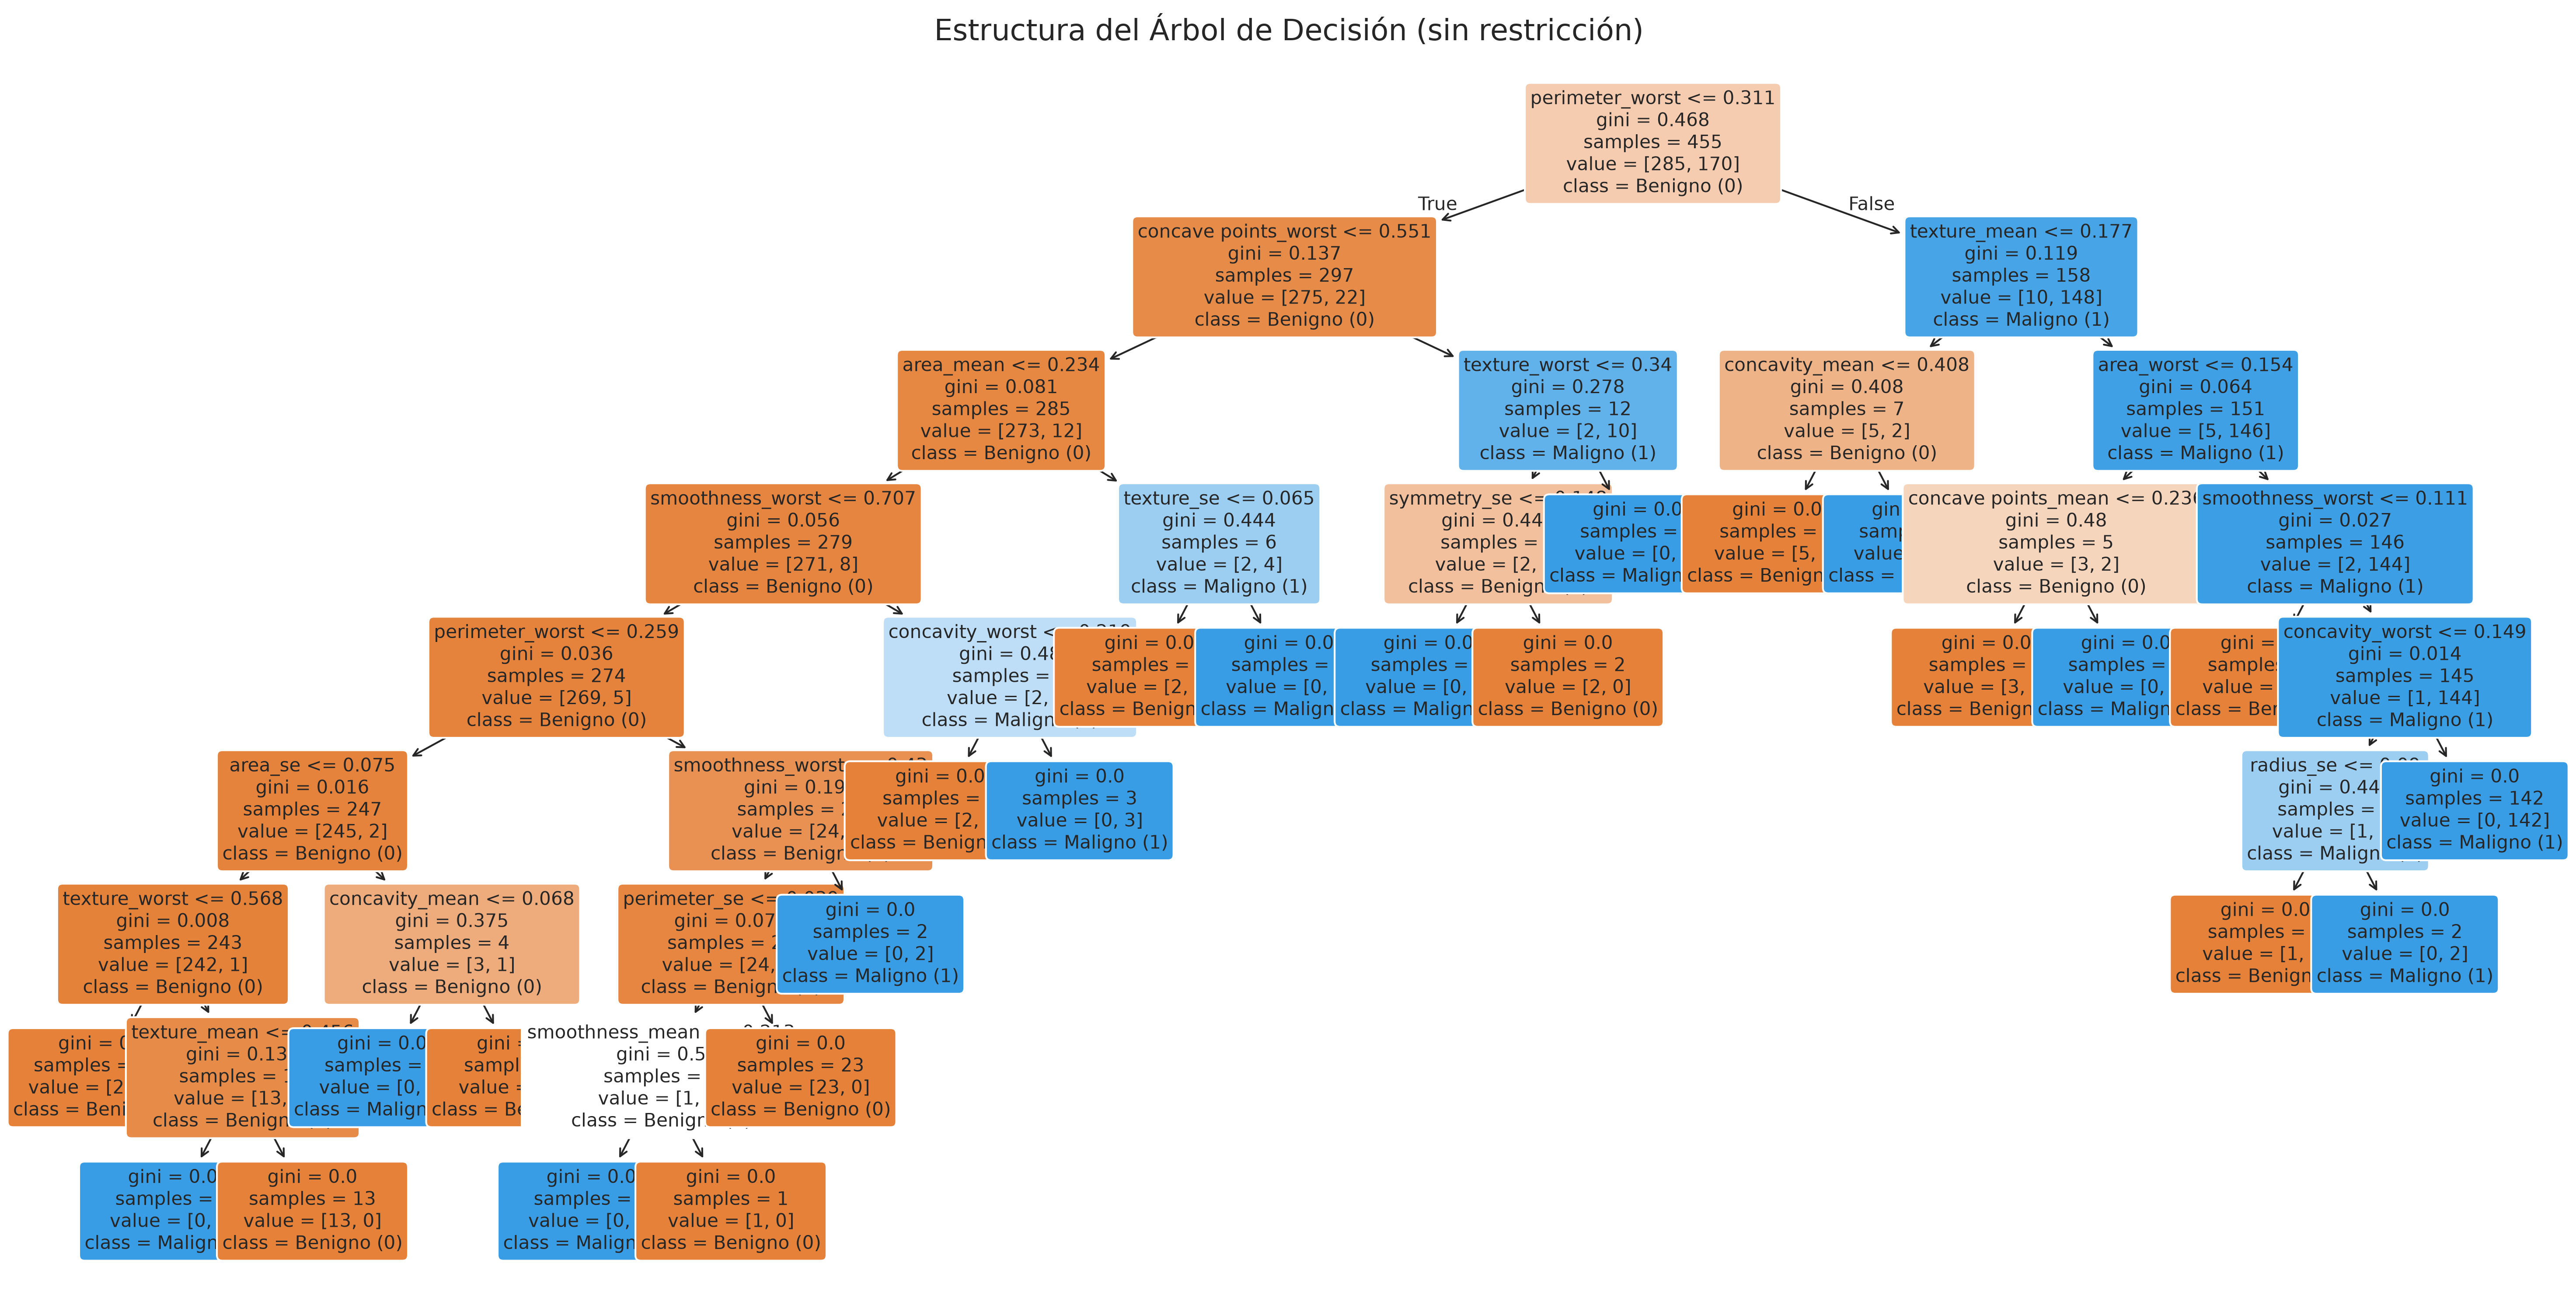

In [217]:
#config
plt.figure(figsize=(20, 10), dpi=300)


plot_tree(
    arbol_decision_sin_rest,
    feature_names=X.columns,
    class_names=['Benigno (0)', 'Maligno (1)'],
    filled=True,
    rounded=True,
    fontsize=10,
    precision=3
)

plt.title("Estructura del Árbol de Decisión (sin restricción)", fontsize=16, pad=20)
plt.tight_layout()
plt.show()

Se logra ver que en el caso del arbol sin restriccion la cantidad nodos por el lado de verdadero es mucho mayor, esto posiblemente por la diferencia de pacientes benignos y malignos en el dataset

# Interpretacion de las metricas

## ¿Qué interpretación se puede dar a los valores de Accuracy, Precision, Recall, F1-score y ROC-AUC?

Primero visualizamos los resultados del arbol de decisión

In [218]:

y_pred_arbol_d3 = arbol_decision.predict(X_test_scaled)
y_probs_arbol_d3 = arbol_decision.predict_proba(X_test_scaled)[:, 1]

acc_d3 = accuracy_score(y_test, y_pred_arbol_d3)
prec_d3 = precision_score(y_test, y_pred_arbol_d3, pos_label=1)
rec_d3 = recall_score(y_test, y_pred_arbol_d3, pos_label=1)
f1_d3 = f1_score(y_test, y_pred_arbol_d3, pos_label=1)
roc_auc_d3 = roc_auc_score(y_test, y_probs_arbol_d3)

# 3. Presentar los resultados en una tabla estructurada
metricas_arbol_d3 = pd.DataFrame({
    'Métrica Descriptor': [
        'Accuracy (Exactitud Global)',
        'Precision (Precisión - Maligno)',
        'Recall (Sensibilidad - Maligno)',
        'F1-Score (Balance Armónico)',
        'ROC-AUC (Área Bajo la Curva)'
    ],
    'Valor Numérico': [acc_d3, prec_d3, rec_d3, f1_d3, roc_auc_d3],
    'Porcentaje': [f"{acc_d3 * 100:.2f}%", f"{prec_d3 * 100:.2f}%", f"{rec_d3 * 100:.2f}%", f"{f1_d3 * 100:.2f}%", f"{roc_auc_d3 * 100:.2f}%"]
})

print("=" * 60)
print("  MÉTRICAS DESCRIPTIVAS - ÁRBOL DE DECISIÓN (max_depth=3)")
print("=" * 60)
print(metricas_arbol_d3.to_string(index=False))

  MÉTRICAS DESCRIPTIVAS - ÁRBOL DE DECISIÓN (max_depth=3)
             Métrica Descriptor  Valor Numérico Porcentaje
    Accuracy (Exactitud Global)        0.912281     91.23%
Precision (Precisión - Maligno)        0.944444     94.44%
Recall (Sensibilidad - Maligno)        0.809524     80.95%
    F1-Score (Balance Armónico)        0.871795     87.18%
   ROC-AUC (Área Bajo la Curva)        0.898644     89.86%


El modelo tiene buenas predicciones: la exactitud global muestra que acertó un 91.23% de los casos benignos y malignos. En precision orientada a células malignas tuvo un acierto del 94.44%. Donde tuvo el peor rendimiento fue en Recall, con 80.95%: evidencia falsos negativos (cánceres clasificados como benignos). Por último, el área bajo la curva ROC es 89.86%, lejos de la aleatoriedad.

Ahora visualizamos el arbol de desicion **sin restriccion**

In [219]:
y_pred_arbol_libre = arbol_decision_sin_rest.predict(X_test_scaled)
y_probs_arbol_libre = arbol_decision_sin_rest.predict_proba(X_test_scaled)[:, 1]

acc_libre = accuracy_score(y_test, y_pred_arbol_libre)
prec_libre = precision_score(y_test, y_pred_arbol_libre, pos_label=1)
rec_libre = recall_score(y_test, y_pred_arbol_libre, pos_label=1)
f1_libre = f1_score(y_test, y_pred_arbol_libre, pos_label=1)
roc_auc_libre = roc_auc_score(y_test, y_probs_arbol_libre)

# 3. Presentar los resultados en una tabla estructurada
metricas_arbol_libre = pd.DataFrame({
    'Métrica Descriptor': [
        'Accuracy (Exactitud Global)',
        'Precision (Precisión - Maligno)',
        'Recall (Sensibilidad - Maligno)',
        'F1-Score (Balance Armónico)',
        'ROC-AUC (Área Bajo la Curva)'
    ],
    'Valor Numérico': [acc_libre, prec_libre, rec_libre, f1_libre, roc_auc_libre],
    'Porcentaje': [f"{acc_libre * 100:.2f}%", f"{prec_libre * 100:.2f}%", f"{rec_libre * 100:.2f}%", f"{f1_libre * 100:.2f}%", f"{roc_auc_libre * 100:.2f}%"]
})

print("=" * 60)
print("  MÉTRICAS DESCRIPTIVAS - ÁRBOL DE DECISIÓN (sin restricción)")
print("=" * 60)
print(metricas_arbol_libre.to_string(index=False))

  MÉTRICAS DESCRIPTIVAS - ÁRBOL DE DECISIÓN (sin restricción)
             Métrica Descriptor  Valor Numérico Porcentaje
    Accuracy (Exactitud Global)        0.929825     92.98%
Precision (Precisión - Maligno)        0.904762     90.48%
Recall (Sensibilidad - Maligno)        0.904762     90.48%
    F1-Score (Balance Armónico)        0.904762     90.48%
   ROC-AUC (Área Bajo la Curva)        0.924603     92.46%


El modelo presenta un rendimiento general aceptable: la exactitud global muestra que logró clasificar correctamente un 92.98% de los casos totales entre benignos y malignos. Luego, en la precisión orientada a la detección de células malignas, alcanzó un 90.48%, lo que indica que cuando el árbol clasifica un tumor como maligno comete pocas falsas alarmas (falsos positivos).

Su recall en la clase maligna también es 90.48%, es decir, detectó cerca del 90% de los casos reales de cáncer y dejó escapar alrededor de un 10% como falsos negativos.

El F1-Score (90.48%) confirma un equilibrio adecuado entre precisión y sensibilidad, mientras que el área bajo la curva (ROC-AUC de 92.46%) demuestra que el modelo mantiene una buena capacidad de discriminación diagnóstica, situándose lejos de la aleatoriedad.

# ¿Mejora la precisión esta vez con el conjunto de entrenamiento y con el conjunto de pruebas?


Para verificarlo se correrán de nuevo los códigos que mostraban la diferencia en la exactitud 

In [220]:
#Con restriccion
acc_train = arbol_decision.score(X_train_scaled, y_train)
acc_test = arbol_decision.score(X_test_scaled, y_test)

#Sin restriccion
acc_train_sin = arbol_decision_sin_rest.score(X_train_scaled, y_train)
acc_test_sin = arbol_decision_sin_rest.score(X_test_scaled, y_test)

print(f"Accuracy en Entrenamiento: {acc_train * 100:.2f}%")
print(f"Accuracy en Prueba:        {acc_test * 100:.2f}%")
print(f"Brecha (Diferencia):       {(acc_train - acc_test) * 100:.2f}%")

print(f"------Sin restriccion-------")

print(f"Accuracy en Entrenamiento: {acc_train_sin * 100:.2f}%")
print(f"Accuracy en Prueba:        {acc_test_sin * 100:.2f}%")
print(f"Brecha (Diferencia):       {(acc_train_sin - acc_test_sin) * 100:.2f}%")

Accuracy en Entrenamiento: 96.70%
Accuracy en Prueba:        91.23%
Brecha (Diferencia):       5.48%
------Sin restriccion-------
Accuracy en Entrenamiento: 100.00%
Accuracy en Prueba:        92.98%
Brecha (Diferencia):       7.02%


Al responder directamente a la pregunta, se observa que en el conjunto de entrenamiento la precisión empeora con la restricción, pasando de 100.00% a 96.70%; y en el conjunto de pruebas también baja, de 92.98% a 91.23%.

Esto demuestra el impacto de la regularización: sin restricción, el árbol logra un 100% en entrenamiento a costa de una brecha del 7.02% en prueba (sobreajuste por memorización). Al limitar la profundidad (max_depth=3), el modelo sacrifica la memorización perfecta en entrenamiento y reduce la brecha a solo 5.48%, es decir, generaliza de forma más estable pero con un acierto en prueba levemente menor.

# Matriz de confusion

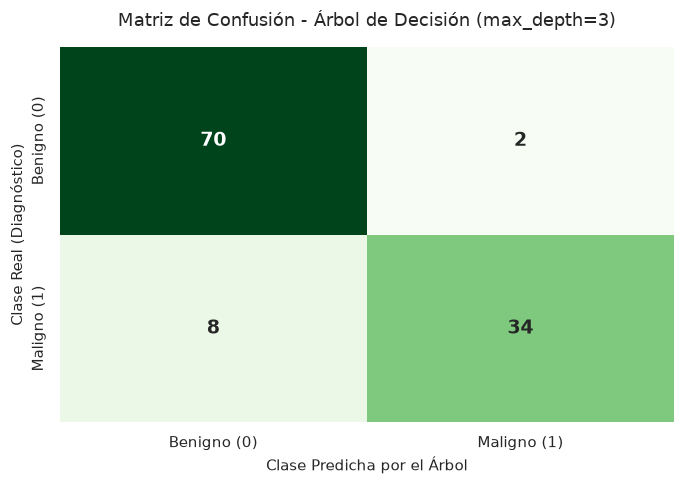

Verdaderos Negativos (TN - Benignos correctos): 70
Falsos Positivos      (FP - Falsa alarma):        2
Falsos Negativos      (FN - Cáncer no detectado): 8
Verdaderos Positivos  (TP - Malignos correctos): 34


In [221]:

y_pred_arbol_d3 = arbol_decision.predict(X_test_scaled)
cm_arbol_d3 = confusion_matrix(y_test, y_pred_arbol_d3)


plt.figure(figsize=(7, 5))
sns.heatmap(
    cm_arbol_d3, 
    annot=True, 
    fmt='d', 
    cmap='Greens', 
    cbar=False,
    xticklabels=['Benigno (0)', 'Maligno (1)'],
    yticklabels=['Benigno (0)', 'Maligno (1)'],
    annot_kws={'size': 14, 'weight': 'bold'}
)

plt.title('Matriz de Confusión - Árbol de Decisión (max_depth=3)', fontsize=13, pad=15)
plt.xlabel('Clase Predicha por el Árbol', fontsize=11)
plt.ylabel('Clase Real (Diagnóstico)', fontsize=11)
plt.tight_layout()
plt.show()

tn_d3, fp_d3, fn_d3, tp_d3 = cm_arbol_d3.ravel()
print(f"Verdaderos Negativos (TN - Benignos correctos): {tn_d3}")
print(f"Falsos Positivos      (FP - Falsa alarma):        {fp_d3}")
print(f"Falsos Negativos      (FN - Cáncer no detectado): {fn_d3}")
print(f"Verdaderos Positivos  (TP - Malignos correctos): {tp_d3}")

El modelo con restricción tiene un gran acierto en benignos (70 verdaderos negativos), pero deja escapar 8 casos malignos como benignos (falsos negativos) y solo comete 2 falsos positivos. Su debilidad principal son los falsos negativos.

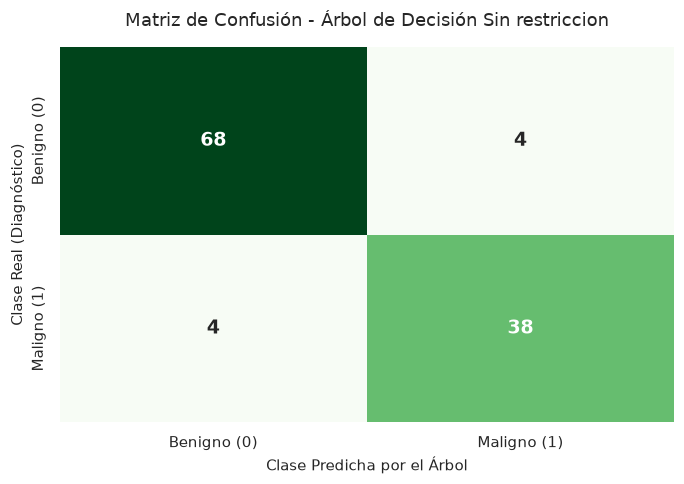

Verdaderos Negativos (TN - Benignos correctos): 68
Falsos Positivos      (FP - Falsa alarma):        4
Falsos Negativos      (FN - Cáncer no detectado): 4
Verdaderos Positivos  (TP - Malignos correctos): 38


In [222]:

y_pred_arbol_libre = arbol_decision_sin_rest.predict(X_test_scaled)
cm_arbol_libre = confusion_matrix(y_test, y_pred_arbol_libre)


plt.figure(figsize=(7, 5))
sns.heatmap(
    cm_arbol_libre, 
    annot=True, 
    fmt='d', 
    cmap='Greens', 
    cbar=False,
    xticklabels=['Benigno (0)', 'Maligno (1)'],
    yticklabels=['Benigno (0)', 'Maligno (1)'],
    annot_kws={'size': 14, 'weight': 'bold'}
)

plt.title('Matriz de Confusión - Árbol de Decisión Sin restriccion', fontsize=13, pad=15)
plt.xlabel('Clase Predicha por el Árbol', fontsize=11)
plt.ylabel('Clase Real (Diagnóstico)', fontsize=11)
plt.tight_layout()
plt.show()

tn_libre, fp_libre, fn_libre, tp_libre = cm_arbol_libre.ravel()
print(f"Verdaderos Negativos (TN - Benignos correctos): {tn_libre}")
print(f"Falsos Positivos      (FP - Falsa alarma):        {fp_libre}")
print(f"Falsos Negativos      (FN - Cáncer no detectado): {fn_libre}")
print(f"Verdaderos Positivos  (TP - Malignos correctos): {tp_libre}")

A diferencia del modelo con restricción de profundidad, este tiene el doble de falsos positivos (4 frente a 2) pero la mitad de falsos negativos (4 frente a 8). Es decir, **detecta mejor los casos de cáncer real**, a costa de más falsas alarmas.

**Conclusion parcial:** el arbol sin restriccion logra un mayor recall en la clase maligna (90,48% frente a 80,95% del arbol con `max_depth=3`), pero a costa de duplicar los falsos positivos (4 frente a 2) y de un sobreajuste claro: alcanza el 100% en entrenamiento con una brecha de 7,02% respecto a prueba. Entre los arboles, el modelo con `max_depth=3` generaliza de forma mas estable y es el recomendado dentro de esta familia. En cualquier caso, ambos arboles son superados por la Regresion Logistica, como se muestra en la comparacion final del Caso 2.

# Comparacion de modelos: Regresion Logistica vs Arboles de Decision


Para decidir el mejor modelo de clasificacion comparamos las metricas de rendimiento de los modelos entrenados sobre el conjunto de prueba (114 registros).


In [223]:
from sklearn.metrics import roc_auc_score

modelos = {
    'Regresion Logistica (base)': (modelo_logistico, X_test_scaled, y_test, X_train_scaled, y_train),
    'Regresion Logistica + GridSearchCV': (mejor_modelo_logistico, X_test_scaled, y_test, X_train_scaled, y_train),
    'Arbol de Decision (max_depth=3)': (arbol_decision, X_test_scaled, y_test, X_train_scaled, y_train),
    'Arbol de Decision (sin restriccion)': (arbol_decision_sin_rest, X_test_scaled, y_test, X_train_scaled, y_train),
    'Regresion Logistica (class_weight balanced)': (modelo_bal, X_test_scaled, y_test, X_train_scaled, y_train),
}

print(f"{'Modelo':45s} {'Acc':>7s} {'Prec(M)':>8s} {'Rec(M)':>7s} {'F1(M)':>7s} {'AUC':>7s} {'Brecha':>7s}")
print('-' * 90)
for nombre, (modelo, X_t, y_t, X_tr, y_tr) in modelos.items():
    y_pred_m = modelo.predict(X_t)
    acc = accuracy_score(y_t, y_pred_m)
    prec = precision_score(y_t, y_pred_m, pos_label=1)
    rec = recall_score(y_t, y_pred_m, pos_label=1)
    f1 = f1_score(y_t, y_pred_m, pos_label=1)
    auc = roc_auc_score(y_t, modelo.predict_proba(X_t)[:, 1])
    brecha = abs(modelo.score(X_tr, y_tr) - acc)
    print(f"{nombre:45s} {acc:7.4f} {prec:8.4f} {rec:7.4f} {f1:7.4f} {auc:7.4f} {brecha*100:6.2f}%")


Modelo                                            Acc  Prec(M)  Rec(M)   F1(M)     AUC  Brecha
------------------------------------------------------------------------------------------
Regresion Logistica (base)                     0.9737   1.0000  0.9286  0.9630  0.9980   0.45%


Regresion Logistica + GridSearchCV             0.9737   1.0000  0.9286  0.9630  0.9980   0.45%
Arbol de Decision (max_depth=3)                0.9123   0.9444  0.8095  0.8718  0.8986   5.48%
Arbol de Decision (sin restriccion)            0.9298   0.9048  0.9048  0.9048  0.9246   7.02%
Regresion Logistica (class_weight balanced)    0.9825   1.0000  0.9524  0.9756  0.9980   0.66%


## Decision del mejor modelo

La **Regresion Logistica** es la mejor familia de modelos para este problema de clasificacion. Dentro de ella, la version con `class_weight='balanced'` logra el mejor equilibrio:

- Mayor exactitud en prueba: **98,25%** (balanced) y **97,37%** (base), frente al 91,23% / 92,98% de los arboles.
- Mejor recall en la clase maligna: **95,24%** (balanced) y **92,86%** (base), frente al 80,95% / 90,48% de los arboles.
- **0 falsos positivos** en ambas variantes; el balanced reduce los falsos negativos de 3 a 2.
- Mejor ROC-AUC: **0,9980** (base) y **0,9980** (balanced), frente al 0,8986 / 0,9246 de los arboles.
- Brecha entrenamiento-prueba de solo 0,45% (base) y 0,66% (balanced), sin sobreajuste; los arboles muestran brechas mayores (5,48% y 7,02%).

El GridSearchCV no mejoro el modelo base (resultados identicos, accuracy 97,37%), por lo que se mantiene la configuracion original `solver='lbfgs'`. Dado que el contexto oncologico penaliza sobre todo los falsos negativos (cancer no detectado), se selecciona la **Regresion Logistica con class_weight='balanced'** como modelo final de clasificacion.

---

# Seleccion y analisis de modelos

## 1. Tabla resumen — Modelos de regresion (Caso 1)

In [224]:
tabla_regresion.round(4)

,MSE,RMSE,MAE,R2 prueba,R2 entrenamiento
Modelo,,,,,
"SVR (rbf, C=1.0, epsilon=0.1)",5.1198,2.2627,1.0108,0.7777,0.6565
KNN (n_neighbors=7),1.6512,1.2850,0.7790,0.9283,0.8906


El mejor modelo de regresion es **KNeighborsRegressor (n_neighbors=7)**: con un RMSE de 1,2850 y un R2 de 0,9283 en prueba, supera al SVR en todas las metricas (MSE 1,6512 frente a 5,1198) y no presenta sobreajuste (R2 de entrenamiento 0,8906, inferior al de prueba).

## 2. Tabla resumen — Modelos de clasificacion (Caso 2)

La comparacion cuantitativa de los modelos de clasificacion se presenta en la tabla "Comparacion de modelos: Regresion Logistica vs Arboles de Decision" al final del Caso 2. El mejor modelo de clasificacion es la **Regresion Logistica**, en particular la version con `class_weight='balanced'`:

- Mayor exactitud en prueba: **98,25%** (balanced) y **97,37%** (base), frente al 91,23% / 92,98% de los arboles.
- Mejor recall en la clase maligna: **95,24%** (balanced) y **92,86%** (base), frente al 80,95% / 90,48% de los arboles.
- **0 falsos positivos**; el balanced reduce los falsos negativos de 3 a 2.
- Mejor ROC-AUC: **0,9980** (base y balanced), frente al 0,8986 / 0,9246 de los arboles.

## 3. Limitaciones y posibles mejoras

- **Dataset pequeno:** 569 registros (cancer) y 301 registros (autos), con una unica particion train/test; los resultados pueden variar con otra semilla o particion. Una validacion cruzada mas robusta daria mayor confianza.
- **Multicolinealidad:** las 30 variables del dataset de cancer miden caracteristicas celulares muy relacionadas (radio, perimetro y area miden el mismo fenomeno en escalas distintas). Se conservaron todas por encargo, pero un analisis de componentes principales (PCA) podria mejorar la estabilidad de los modelos.
- **SVR con subajuste:** la configuracion fija del SVR (C=1,0, epsilon=0,1) se quedo corta; una búsqueda de hiperparametros podria mejorarla, aunque el KNN ya lo supera ampliamente.
- **Desbalance en cancer:** se mitigo con `stratify=y` y se evaluo `class_weight='balanced'`; un muestreo SMOTE seria una alternativa adicional a evaluar.

# Fuentes

https://medium.com/@azizozmen/understanding-multicollinearity-its-impact-on-data-analysis-and-machine-learning-94da6620569e

https://medium.com/@hhuseyincosgun/which-data-scaling-technique-should-i-use-a1615292061e